# Fase 3 — Efecto base de cada VI de tarea sobre cada VD

**Objetivo:** Cuantificar el **efecto marginal** ("base") de cada variable independiente de tarea (VI) sobre cada variable dependiente normalizada (VD/min), sin considerar las demás VI ni GrupoEdad. Este análisis proporciona un **valor de referencia** que luego se contrastará con los efectos ajustados de los modelos GLMM.

**Dataset:** `Matriz_V3.xlsx` (3 179 filas × 18 columnas).

| VD normalizada | Descripción |
|---|---|
| `Total Touches / min` | Toques totales por minuto |
| `Golpeos +15 m/s / min` | Golpeos de alta velocidad por minuto |
| `Distance Covered (m) / min` | Distancia total recorrida por minuto |
| `High Intensity Distance (20 km/h) / min` | Distancia de alta intensidad por minuto |

| VI de tarea | Descripción |
|---|---|
| `Formato_del_Juego` | Formato del juego: SSG (espacio reducido + grupo pequeño) vs LSG (espacio amplio + grupo grande) |
| `Polaridad` | Presencia o ausencia de polarización |
| `Equilibrio` | Equilibrio numérico entre equipos |

In [1]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings

# ── Configuración global ──────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 12,
    "axes.labelpad": 8,
    "grid.alpha": 0.30,
    "grid.linewidth": 0.5,
    "grid.color": "#CCCCCC",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})
%matplotlib inline

# ── Carga del dataset ─────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# ── Variables dependientes normalizadas ───────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]

vd_labels = [
    "Toques / min",
    "Golpeos +15 m/s / min",
    "Distancia (m) / min",
    "HID (m) / min",
]

vd_to_label = dict(zip(vd_cols, vd_labels))

# ── Variables independientes de tarea ─────────────────────
vi_cols = ["Formato_del_Juego", "Polaridad", "Equilibrio"]

# ── Paletas de colores ────────────────────────────────────
# Paleta para las 4 VD (consistente con notebooks anteriores)
colores_vd = sns.color_palette("Set2", n_colors=len(vd_cols))
vd_to_color = dict(zip(vd_cols, colores_vd))

# Paleta para comparación de niveles de VI (2 colores contrastantes)
PAL_NIVEL = ["#5A9BD5", "#F28E2B"]  # Azul acero · Naranja cálido

# ── Verificación ──────────────────────────────────────────
for col in vd_cols + vi_cols:
    assert col in df.columns, f"Columna '{col}' no encontrada."
print(f"✔ {len(vd_cols)} VD y {len(vi_cols)} VI verificadas.")

Dimensiones: 3179 filas × 18 columnas
✔ 4 VD y 3 VI verificadas.


---
## Verificación previa — Niveles de cada VI

Antes de iniciar los análisis, inspeccionamos los niveles únicos y sus frecuencias para cada VI. Esto determina si cada VI es **binaria** (→ t-test, Cohen's *d*) o tiene **>2 niveles** (→ Welch ANOVA, η², comparaciones post-hoc).

In [2]:
# ── Niveles y frecuencias de cada VI ──────────────────────
vi_niveles = {}  # dict VI → lista de niveles (ordenados)

for vi in vi_cols:
    vc = df[vi].value_counts().sort_index()
    vi_niveles[vi] = sorted(df[vi].dropna().unique().tolist())
    n_niveles = len(vi_niveles[vi])
    tipo = "binaria" if n_niveles == 2 else f"multinivel ({n_niveles} niveles)"
    print(f"\n{'─'*50}")
    print(f"VI: {vi}  →  {tipo}")
    print(f"{'─'*50}")
    for nivel, n in vc.items():
        print(f"  {nivel:>20s} : {n:>5d}  ({n/len(df)*100:.1f}%)")

print("\n✔ Resumen: todas las VI son binarias → se usarán t-test de Welch y Cohen's d.")


──────────────────────────────────────────────────
VI: Formato_del_Juego  →  binaria
──────────────────────────────────────────────────
                   LSG :  1637  (51.5%)
                   SSG :  1542  (48.5%)

──────────────────────────────────────────────────
VI: Polaridad  →  binaria
──────────────────────────────────────────────────
         No_polarizado :   649  (20.4%)
            Polarizado :  2530  (79.6%)

──────────────────────────────────────────────────
VI: Equilibrio  →  binaria
──────────────────────────────────────────────────
         Desequilibrio :   798  (25.1%)
            Equilibrio :  2381  (74.9%)

✔ Resumen: todas las VI son binarias → se usarán t-test de Welch y Cohen's d.


In [3]:
# ── Funciones auxiliares ───────────────────────────────────

def cohen_d(g1, g2):
    """Cohen's d con SD pooled."""
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(ddof=1), g2.var(ddof=1)
    sp = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / sp if sp > 0 else 0.0


def interpretar_d(d):
    """Interpretación del tamaño del efecto según Cohen."""
    ad = abs(d)
    if ad < 0.2:
        return "Negligible"
    elif ad < 0.5:
        return "Pequeño"
    elif ad < 0.8:
        return "Medio"
    else:
        return "Grande"


def ic_95(x):
    """Intervalo de confianza al 95% de la media."""
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(len(x))
    return m - 1.96 * se, m + 1.96 * se


def welch_anova_manual(groups):
    """Welch ANOVA para >2 grupos (Alexander-Govern approximation)."""
    return stats.alexandergovern(*groups)


print("✔ Funciones auxiliares definidas.")

✔ Funciones auxiliares definidas.


---
## 1. Tablas descriptivas por nivel de cada VI

Para cada combinación VI × VD se calculan los descriptivos por nivel: N, media, SD, mediana e IC 95% de la media.

In [4]:
# ── Tablas descriptivas por VI ────────────────────────────
from IPython.display import display, Markdown

for vi in vi_cols:
    niveles = vi_niveles[vi]
    filas = []
    for nivel in niveles:
        sub = df[df[vi] == nivel]
        for vd, label in zip(vd_cols, vd_labels):
            x = sub[vd].dropna()
            lo, hi = ic_95(x)
            filas.append({
                "Nivel": nivel,
                "VD": label,
                "N": len(x),
                "Media": round(x.mean(), 3),
                "SD": round(x.std(ddof=1), 3),
                "Mediana": round(x.median(), 3),
                "IC 95% inf": round(lo, 3),
                "IC 95% sup": round(hi, 3),
            })
    tabla = pd.DataFrame(filas)
    display(Markdown(f"### VI: **{vi}**"))
    display(tabla)

### VI: **Formato_del_Juego**

,Nivel,VD,N,Media,SD,Mediana,IC 95% inf,IC 95% sup
0,LSG,Toques / min,1637,1.708,0.915,1.545,1.664,1.752
1,LSG,Golpeos +15 m/s / min,1637,0.159,0.168,0.120,0.151,0.167
2,LSG,Distancia (m) / min,1637,92.248,28.495,97.500,90.867,93.628
3,LSG,HID (m) / min,1637,2.499,2.831,1.542,2.361,2.636
4,SSG,Toques / min,1542,3.205,1.888,2.909,3.111,3.300
5,SSG,Golpeos +15 m/s / min,1542,0.143,0.172,0.095,0.135,0.152
6,SSG,Distancia (m) / min,1542,67.913,20.408,67.326,66.894,68.931
7,SSG,HID (m) / min,1542,0.754,1.450,0.143,0.682,0.827


### VI: **Polaridad**

,Nivel,VD,N,Media,SD,Mediana,IC 95% inf,IC 95% sup
0,No_polarizado,Toques / min,649,3.552,1.936,3.200,3.403,3.701
1,No_polarizado,Golpeos +15 m/s / min,649,0.102,0.155,0.059,0.090,0.114
2,No_polarizado,Distancia (m) / min,649,75.870,24.967,75.111,73.949,77.791
3,No_polarizado,HID (m) / min,649,0.818,1.667,0.077,0.690,0.946
4,Polarizado,Toques / min,2530,2.148,1.433,1.812,2.092,2.204
5,Polarizado,Golpeos +15 m/s / min,2530,0.164,0.172,0.129,0.157,0.171
6,Polarizado,Distancia (m) / min,2530,81.617,28.258,81.879,80.516,82.718
7,Polarizado,HID (m) / min,2530,1.867,2.546,0.800,1.767,1.966


### VI: **Equilibrio**

,Nivel,VD,N,Media,SD,Mediana,IC 95% inf,IC 95% sup
0,Desequilibrio,Toques / min,798,3.257,1.932,2.935,3.123,3.391
1,Desequilibrio,Golpeos +15 m/s / min,798,0.134,0.183,0.077,0.122,0.147
2,Desequilibrio,Distancia (m) / min,798,71.052,24.960,68.562,69.320,72.784
3,Desequilibrio,HID (m) / min,798,0.923,1.733,0.100,0.803,1.044
4,Equilibrio,Toques / min,2381,2.159,1.442,1.815,2.101,2.217
5,Equilibrio,Golpeos +15 m/s / min,2381,0.157,0.166,0.120,0.150,0.164
6,Equilibrio,Distancia (m) / min,2381,83.592,27.880,85.294,82.472,84.711
7,Equilibrio,HID (m) / min,2381,1.897,2.577,0.824,1.793,2.000


---
## 1b. Análisis de inflación de ceros (Golpeos y HID)

Las variables **Golpeos +15 m/s / min** y **HID (m) / min** presentan una proporción elevada de valores exactamente iguales a 0. Esto indica que en muchas observaciones el jugador no registró ningún golpeo de alta velocidad ni distancia a alta intensidad durante la tarea. La media aritmética convencional mezcla dos fenómenos distintos:

1. **Efecto "interruptor" (on/off):** La VI modifica la *probabilidad* de que ocurra al menos un evento (es decir, cambia el % de ceros).
2. **Efecto "modulador" (intensidad):** La VI modifica la *magnitud* del evento cuando este sí ocurre (es decir, cambia la media condicional entre los valores > 0).

Descomponer ambos efectos es fundamental para decidir si los GLMM de la fase siguiente deben usar una distribución continua estándar (Gamma) o un modelo *hurdle* / *zero-inflated* que modele explícitamente la probabilidad de cero.

In [5]:
# ── 1b.1  Tabla descriptiva ampliada: inflación de ceros ──
from IPython.display import display, Markdown

# VD con inflación de ceros
vd_zeros = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels = ["Golpeos +15 m/s / min", "HID (m) / min"]

filas_zeros = []

for vd, label in zip(vd_zeros, vd_zeros_labels):
    # ── Fila global (sin segmentar por VI) ────────────────
    x = df[vd].dropna()
    x_pos = x[x > 0]
    filas_zeros.append({
        "VI": "— GLOBAL —",
        "Nivel": "Todos",
        "VD": label,
        "N total": len(x),
        "N ceros": int((x == 0).sum()),
        "% ceros": round((x == 0).mean() * 100, 1),
        "Media global": round(x.mean(), 4),
        "Media cond. (>0)": round(x_pos.mean(), 4) if len(x_pos) > 0 else np.nan,
        "Mediana cond. (>0)": round(x_pos.median(), 4) if len(x_pos) > 0 else np.nan,
        "SD cond. (>0)": round(x_pos.std(ddof=1), 4) if len(x_pos) > 1 else np.nan,
    })

    # ── Filas por nivel de cada VI ────────────────────────
    for vi in vi_cols:
        for nivel in vi_niveles[vi]:
            sub = df.loc[df[vi] == nivel, vd].dropna()
            sub_pos = sub[sub > 0]
            filas_zeros.append({
                "VI": vi,
                "Nivel": nivel,
                "VD": label,
                "N total": len(sub),
                "N ceros": int((sub == 0).sum()),
                "% ceros": round((sub == 0).mean() * 100, 1),
                "Media global": round(sub.mean(), 4),
                "Media cond. (>0)": round(sub_pos.mean(), 4) if len(sub_pos) > 0 else np.nan,
                "Mediana cond. (>0)": round(sub_pos.median(), 4) if len(sub_pos) > 0 else np.nan,
                "SD cond. (>0)": round(sub_pos.std(ddof=1), 4) if len(sub_pos) > 1 else np.nan,
            })

df_zeros = pd.DataFrame(filas_zeros)

# Mostrar separadamente por VD
for label in vd_zeros_labels:
    display(Markdown(f"### 1b.1 — Descriptivos de ceros: **{label}**"))
    display(df_zeros[df_zeros["VD"] == label].reset_index(drop=True))

### 1b.1 — Descriptivos de ceros: **Golpeos +15 m/s / min**

,VI,Nivel,VD,N total,N ceros,% ceros,Media global,Media cond. (>0),Mediana cond. (>0),SD cond. (>0)
0,— GLOBAL —,Todos,Golpeos +15 m/s / min,3179,873,27.5,0.1513,0.2086,0.1600,0.1675
1,Formato_del_Juego,LSG,Golpeos +15 m/s / min,1637,333,20.3,0.1589,0.1994,0.1538,0.1657
2,Formato_del_Juego,SSG,Golpeos +15 m/s / min,1542,540,35.0,0.1433,0.2205,0.1765,0.1692
3,Polaridad,No_polarizado,Golpeos +15 m/s / min,649,296,45.6,0.1021,0.1877,0.1250,0.1674
4,Polaridad,Polarizado,Golpeos +15 m/s / min,2530,577,22.8,0.1639,0.2124,0.1667,0.1673
5,Equilibrio,Desequilibrio,Golpeos +15 m/s / min,798,312,39.1,0.1342,0.2203,0.1667,0.1892
6,Equilibrio,Equilibrio,Golpeos +15 m/s / min,2381,561,23.6,0.1570,0.2055,0.1579,0.1612


### 1b.1 — Descriptivos de ceros: **HID (m) / min**

,VI,Nivel,VD,N total,N ceros,% ceros,Media global,Media cond. (>0),Mediana cond. (>0),SD cond. (>0)
0,— GLOBAL —,Todos,HID (m) / min,3179,928,29.2,1.6526,2.3339,1.3636,2.5976
1,Formato_del_Juego,LSG,HID (m) / min,1637,296,18.1,2.4986,3.0501,2.1818,2.8458
2,Formato_del_Juego,SSG,HID (m) / min,1542,632,41.0,0.7544,1.2784,0.6910,1.7006
3,Polaridad,No_polarizado,HID (m) / min,649,292,45.0,0.8180,1.4870,0.7273,2.0149
4,Polaridad,Polarizado,HID (m) / min,2530,636,25.1,1.8667,2.4935,1.5333,2.6638
5,Equilibrio,Desequilibrio,HID (m) / min,798,346,43.4,0.9234,1.6303,0.8787,2.0377
6,Equilibrio,Equilibrio,HID (m) / min,2381,582,24.4,1.8970,2.5106,1.5294,2.6920


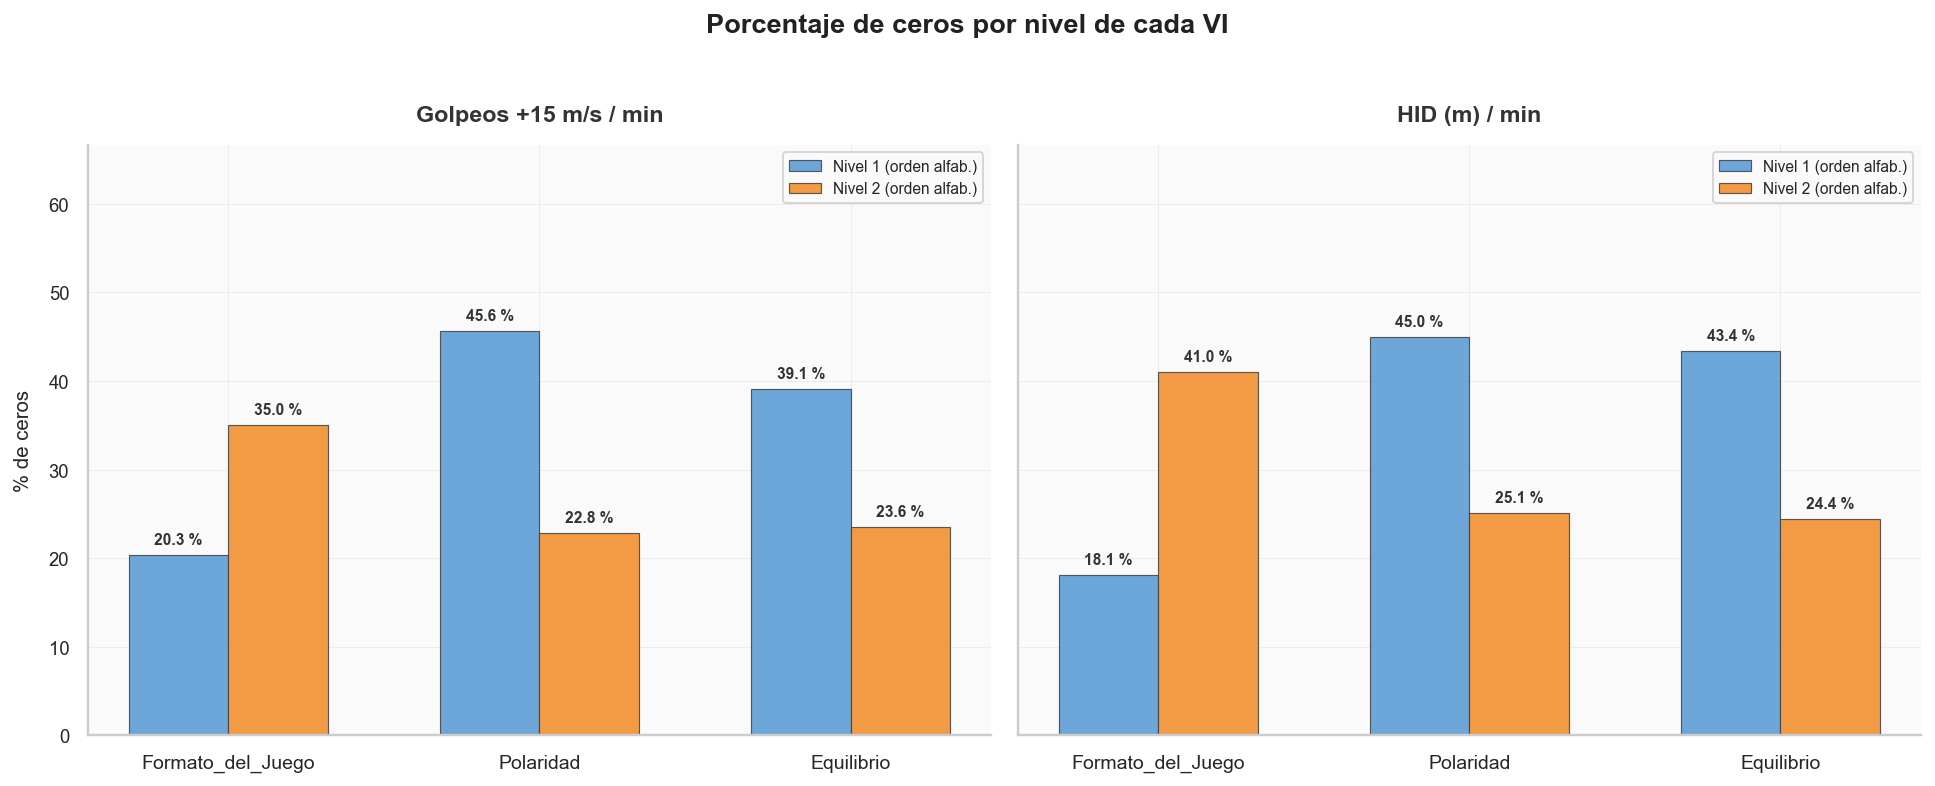

In [6]:
# ── 1b.2  Barras agrupadas: % de ceros por nivel de cada VI ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for idx_vd, (vd, label) in enumerate(zip(vd_zeros, vd_zeros_labels)):
    ax = axes[idx_vd]
    x_positions = np.arange(len(vi_cols))
    bar_w = 0.32

    for j_niv in range(2):  # 2 niveles por VI
        pcts = []
        labels_niv = []
        for vi in vi_cols:
            nivel = vi_niveles[vi][j_niv]
            sub = df.loc[df[vi] == nivel, vd].dropna()
            pcts.append((sub == 0).mean() * 100)
            labels_niv.append(nivel)

        offset = (j_niv - 0.5) * bar_w
        bars = ax.bar(
            x_positions + offset, pcts, width=bar_w,
            color=PAL_NIVEL[j_niv], edgecolor="#444", linewidth=0.6,
            label=f"Nivel {j_niv + 1}", alpha=0.88,
        )
        # Anotar porcentaje
        for bar, pct_val in zip(bars, pcts):
            ax.annotate(
                f"{pct_val:.1f} %", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                fontsize=8, ha="center", va="bottom", fontweight="bold", color="#333",
                xytext=(0, 4), textcoords="offset points",
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(vi_cols, fontsize=10)
    ax.set_ylabel("% de ceros" if idx_vd == 0 else "", fontsize=10.5)
    ax.set_title(label, fontsize=12, fontweight="bold", color="#333")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)

    # Leyenda con nombres reales de niveles
    handles = [
        plt.Rectangle((0, 0), 1, 1, fc=PAL_NIVEL[0], ec="#444", lw=0.6, alpha=0.88),
        plt.Rectangle((0, 0), 1, 1, fc=PAL_NIVEL[1], ec="#444", lw=0.6, alpha=0.88),
    ]
    leg_labels = ["Nivel 1 (orden alfab.)", "Nivel 2 (orden alfab.)"]
    ax.legend(handles, leg_labels, fontsize=8, loc="upper right")

fig.suptitle(
    "Porcentaje de ceros por nivel de cada VI",
    fontsize=14, fontweight="bold", color="#222", y=1.02,
)
fig.tight_layout()
plt.show()

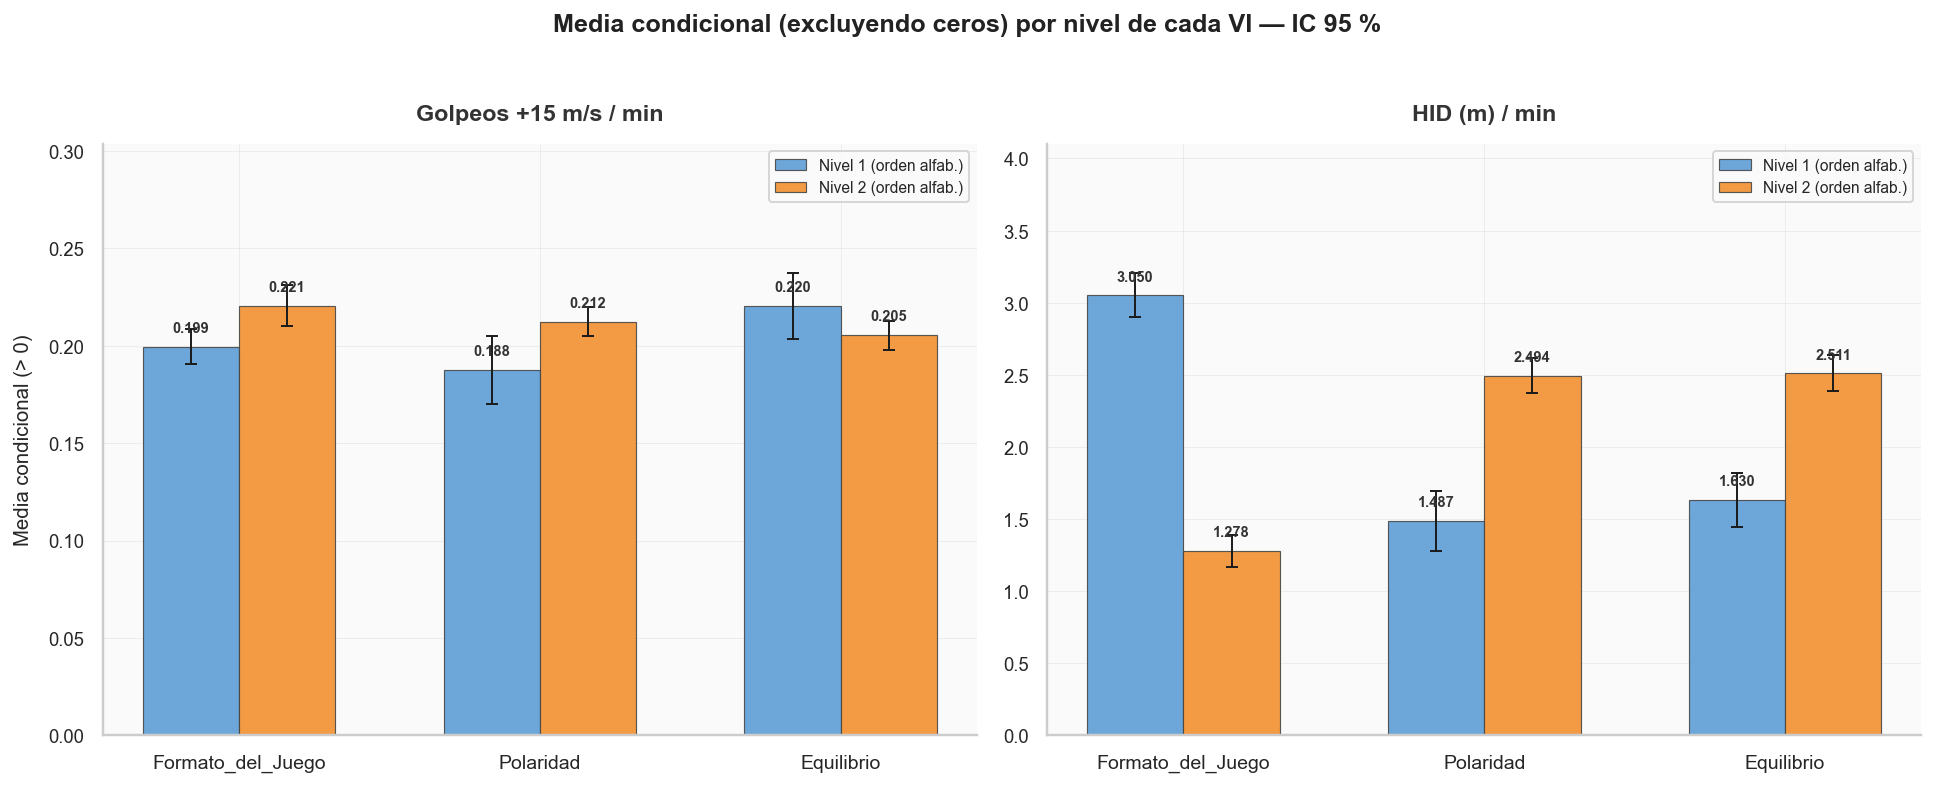

In [7]:
# ── 1b.3  Barras agrupadas: media condicional (> 0) por nivel de cada VI ──

from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for idx_vd, (vd, label) in enumerate(zip(vd_zeros, vd_zeros_labels)):
    ax = axes[idx_vd]
    x_positions = np.arange(len(vi_cols))
    bar_w = 0.32

    for j_niv in range(2):
        means, ci_lo, ci_hi = [], [], []
        for vi in vi_cols:
            nivel = vi_niveles[vi][j_niv]
            sub = df.loc[(df[vi] == nivel) & (df[vd] > 0), vd].dropna()
            m = sub.mean()
            se = sub.std(ddof=1) / np.sqrt(len(sub)) if len(sub) > 1 else 0
            means.append(m)
            ci_lo.append(1.96 * se)
            ci_hi.append(1.96 * se)

        offset = (j_niv - 0.5) * bar_w
        bars = ax.bar(
            x_positions + offset, means, width=bar_w,
            color=PAL_NIVEL[j_niv], edgecolor="#444", linewidth=0.6,
            yerr=[ci_lo, ci_hi], capsize=3, error_kw={"lw": 1, "color": "#555"},
            label=f"Nivel {j_niv + 1}", alpha=0.88,
        )
        for bar, m_val in zip(bars, means):
            ax.annotate(
                f"{m_val:.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                fontsize=7.5, ha="center", va="bottom", fontweight="bold", color="#333",
                xytext=(0, 6), textcoords="offset points",
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(vi_cols, fontsize=10)
    ax.set_ylabel("Media condicional (> 0)" if idx_vd == 0 else "", fontsize=10.5)
    ax.set_title(label, fontsize=12, fontweight="bold", color="#333")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.22)

    handles = [
        plt.Rectangle((0, 0), 1, 1, fc=PAL_NIVEL[0], ec="#444", lw=0.6, alpha=0.88),
        plt.Rectangle((0, 0), 1, 1, fc=PAL_NIVEL[1], ec="#444", lw=0.6, alpha=0.88),
    ]
    ax.legend(handles, ["Nivel 1 (orden alfab.)", "Nivel 2 (orden alfab.)"],
              fontsize=8, loc="upper right")

fig.suptitle(
    "Media condicional (excluyendo ceros) por nivel de cada VI — IC 95 %",
    fontsize=13, fontweight="bold", color="#222", y=1.02,
)
fig.tight_layout()
plt.show()

In [8]:
# ── 1b.4  Tabla resumen: Interruptor vs Modulador vs Ambos ──

umbral_pct_ceros = 5.0   # pp de diferencia en % ceros para considerar "Interruptor"
umbral_pct_media = 10.0  # % de diferencia relativa en media cond. para considerar "Modulador"

resumen_rows = []

for vd, label in zip(vd_zeros, vd_zeros_labels):
    for vi in vi_cols:
        niveles = vi_niveles[vi]
        stats_por_nivel = {}
        for nivel in niveles:
            sub = df.loc[df[vi] == nivel, vd].dropna()
            sub_pos = sub[sub > 0]
            stats_por_nivel[nivel] = {
                "pct_ceros": (sub == 0).mean() * 100,
                "media_global": sub.mean(),
                "media_cond": sub_pos.mean() if len(sub_pos) > 0 else np.nan,
            }
        n1, n2 = niveles
        d_pct = abs(stats_por_nivel[n1]["pct_ceros"] - stats_por_nivel[n2]["pct_ceros"])
        media_ref = max(stats_por_nivel[n1]["media_cond"], stats_por_nivel[n2]["media_cond"])
        d_media = (
            abs(stats_por_nivel[n1]["media_cond"] - stats_por_nivel[n2]["media_cond"])
            / media_ref * 100 if media_ref > 0 else 0
        )

        es_inter = d_pct >= umbral_pct_ceros
        es_modul = d_media >= umbral_pct_media
        if es_inter and es_modul:
            interp = "Ambos"
        elif es_inter:
            interp = "Interruptor"
        elif es_modul:
            interp = "Modulador"
        else:
            interp = "Neutro"

        for nivel in niveles:
            s = stats_por_nivel[nivel]
            resumen_rows.append({
                "VD": label, "VI": vi, "Nivel": nivel,
                "% ceros": round(s["pct_ceros"], 1),
                "Media global": round(s["media_global"], 4),
                "Media cond. (>0)": round(s["media_cond"], 4) if not np.isnan(s["media_cond"]) else "—",
                "Δ % ceros (pp)": round(d_pct, 1),
                "Δ % media cond.": f"{d_media:.1f} %",
                "Clasificación": interp,
            })

df_resumen_ceros = pd.DataFrame(resumen_rows)

# Estilo con colores según clasificación
def _color_clasif(val):
    mapa = {"Interruptor": "#FFF3CD", "Modulador": "#D1ECF1",
            "Ambos": "#F8D7DA", "Neutro": "#D4EDDA"}
    return f"background-color: {mapa.get(val, '')}"

display(
    df_resumen_ceros.style
    .set_caption("Resumen: mecanismo de efecto de cada VI sobre VDs con inflación de ceros")
    .map(_color_clasif, subset=["Clasificación"])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

print(f"\nUmbrales aplicados → Interruptor: Δ % ceros ≥ {umbral_pct_ceros} pp | "
      f"Modulador: Δ % media cond. ≥ {umbral_pct_media} %")

,VD,VI,Nivel,% ceros,Media global,Media cond. (>0),Δ % ceros (pp),Δ % media cond.,Clasificación
0,Golpeos +15 m/s / min,Formato_del_Juego,LSG,20.300000,0.158900,0.199400,14.700000,9.6 %,Interruptor
1,Golpeos +15 m/s / min,Formato_del_Juego,SSG,35.000000,0.143300,0.220500,14.700000,9.6 %,Interruptor
2,Golpeos +15 m/s / min,Polaridad,No_polarizado,45.600000,0.102100,0.187700,22.800000,11.6 %,Ambos
3,Golpeos +15 m/s / min,Polaridad,Polarizado,22.800000,0.163900,0.212400,22.800000,11.6 %,Ambos
4,Golpeos +15 m/s / min,Equilibrio,Desequilibrio,39.100000,0.134200,0.220300,15.500000,6.7 %,Interruptor
5,Golpeos +15 m/s / min,Equilibrio,Equilibrio,23.600000,0.157000,0.205500,15.500000,6.7 %,Interruptor
6,HID (m) / min,Formato_del_Juego,LSG,18.100000,2.498600,3.050100,22.900000,58.1 %,Ambos
7,HID (m) / min,Formato_del_Juego,SSG,41.000000,0.754400,1.278400,22.900000,58.1 %,Ambos
8,HID (m) / min,Polaridad,No_polarizado,45.000000,0.818000,1.487000,19.900000,40.4 %,Ambos
9,HID (m) / min,Polaridad,Polarizado,25.100000,1.866700,2.493500,19.900000,40.4 %,Ambos



Umbrales aplicados → Interruptor: Δ % ceros ≥ 5.0 pp | Modulador: Δ % media cond. ≥ 10.0 %


In [9]:
# ── 1b.5  Test χ² de independencia: proporción de ceros por nivel de VI ──

from scipy.stats import chi2_contingency

chi2_rows = []

for vd, label in zip(vd_zeros, vd_zeros_labels):
    for vi in vi_cols:
        niveles = vi_niveles[vi]
        # Tabla de contingencia 2×2: nivel × (cero / no-cero)
        tabla = np.zeros((2, 2), dtype=int)
        for i_niv, nivel in enumerate(niveles):
            sub = df.loc[df[vi] == nivel, vd].dropna()
            n_ceros = int((sub == 0).sum())
            n_pos = int((sub > 0).sum())
            tabla[i_niv] = [n_ceros, n_pos]

        chi2, p, dof, expected = chi2_contingency(tabla, correction=True)

        # Odds Ratio (Haldane-Anscombe) — sumar 0.5 por seguridad
        a, b = tabla[0]
        c, d_val = tabla[1]
        OR = (a * d_val) / (b * c) if (b * c) > 0 else np.nan
        log_or = np.log(OR) if OR > 0 else np.nan
        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d_val) if min(a, b, c, d_val) > 0 else np.nan
        or_lo = np.exp(log_or - 1.96 * se_log_or) if not np.isnan(se_log_or) else np.nan
        or_hi = np.exp(log_or + 1.96 * se_log_or) if not np.isnan(se_log_or) else np.nan

        signif = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

        chi2_rows.append({
            "VD": label, "VI": vi,
            f"% ceros ({niveles[0]})": round((tabla[0, 0] / tabla[0].sum()) * 100, 1),
            f"% ceros ({niveles[1]})": round((tabla[1, 0] / tabla[1].sum()) * 100, 1),
            "χ²": round(chi2, 2), "gl": dof,
            "p-valor": f"{p:.2e}" if p < 0.001 else f"{p:.4f}",
            "OR": round(OR, 3) if not np.isnan(OR) else "—",
            "IC 95 % OR": f"[{or_lo:.3f}, {or_hi:.3f}]" if not np.isnan(or_lo) else "—",
            "Sig.": signif,
        })

df_chi2 = pd.DataFrame(chi2_rows)

def _color_sig(val):
    if val in ("***", "**"):
        return "background-color: #F8D7DA; font-weight: bold"
    elif val == "*":
        return "background-color: #FFF3CD"
    return ""

display(
    df_chi2.style
    .set_caption("Test χ² de independencia — proporción de ceros entre niveles de cada VI")
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

print("\nNota: OR > 1 indica que el primer nivel (orden alfabético) tiene mayor odds de presentar ceros.")

,VD,VI,% ceros (LSG),% ceros (SSG),χ²,gl,p-valor,OR,IC 95 % OR,Sig.,% ceros (No_polarizado),% ceros (Polarizado),% ceros (Desequilibrio),% ceros (Equilibrio)
0,Golpeos +15 m/s / min,Formato_del_Juego,20.300000,35.000000,85.140000,1,2.79e-20,0.474000,"[0.404, 0.556]",***,nan,nan,nan,nan
1,Golpeos +15 m/s / min,Polaridad,nan,nan,133.670000,1,6.44e-31,2.838000,"[2.370, 3.399]",***,45.600000,22.800000,nan,nan
2,Golpeos +15 m/s / min,Equilibrio,nan,nan,71.640000,1,2.58e-17,2.083000,"[1.756, 2.471]",***,nan,nan,39.100000,23.600000
3,HID (m) / min,Formato_del_Juego,18.100000,41.000000,200.410000,1,1.70e-45,0.318000,"[0.270, 0.374]",***,nan,nan,nan,nan
4,HID (m) / min,Polaridad,nan,nan,97.540000,1,5.28e-23,2.436000,"[2.037, 2.913]",***,45.000000,25.100000,nan,nan
5,HID (m) / min,Equilibrio,nan,nan,102.540000,1,4.23e-24,2.366000,"[2.000, 2.800]",***,nan,nan,43.400000,24.400000



Nota: OR > 1 indica que el primer nivel (orden alfabético) tiene mayor odds de presentar ceros.


### 1b.6 — Interpretación del análisis de inflación de ceros

**Resumen de hallazgos:**

| Concepto | Definición operativa |
|---|---|
| **Interruptor** | La VI modifica significativamente la *probabilidad* de que la métrica sea exactamente 0, sin alterar demasiado la intensidad cuando sí se produce la acción. |
| **Modulador** | La VI no cambia la proporción de ceros, pero sí la *intensidad* (media condicional) cuando la acción ocurre. |
| **Ambos** | La VI afecta tanto la probabilidad de ocurrencia como la intensidad. |

**Implicaciones metodológicas:**

1. **Golpeos +15 m/s / min** y **HID (m) / min** presentan un ~30 % de observaciones con valor exactamente 0. Esto invalida el supuesto de normalidad de un modelo lineal clásico.
2. La tabla de clasificación (1b.4) y los tests χ² (1b.5) permiten identificar **qué VIs actúan como interruptores** (cambian la probabilidad de que el evento ocurra) y cuáles como **moduladores** (cambian la magnitud dado que ocurre).
3. Este doble mecanismo justifica el uso en fases posteriores de:
   - **Modelos Hurdle** (dos partes: logística para 0/no-0 + gamma/log-normal para la parte positiva), o
   - **Modelos Zero-Inflated** (mezcla de un proceso generador de ceros estructurales y un proceso de conteo/continuo).
4. Las VIs clasificadas como "Interruptor" deberían incluirse en la **parte logística** del modelo hurdle; las clasificadas como "Modulador" en la **parte continua**; las "Ambos" en ambas partes.

> **Conclusión provisional**: El análisis descriptivo de la inflación de ceros confirma que un enfoque en dos partes es necesario para Golpeos y HID, y proporciona orientación sobre qué predictores incluir en cada componente del modelo.

---
## 2. Gráficos de comparación por VI

Para cada VI se presentan tres tipos de visualización: **boxplots**, **violin plots** y **barplots de medias con IC 95%**.

### 2a. Boxplots lado a lado

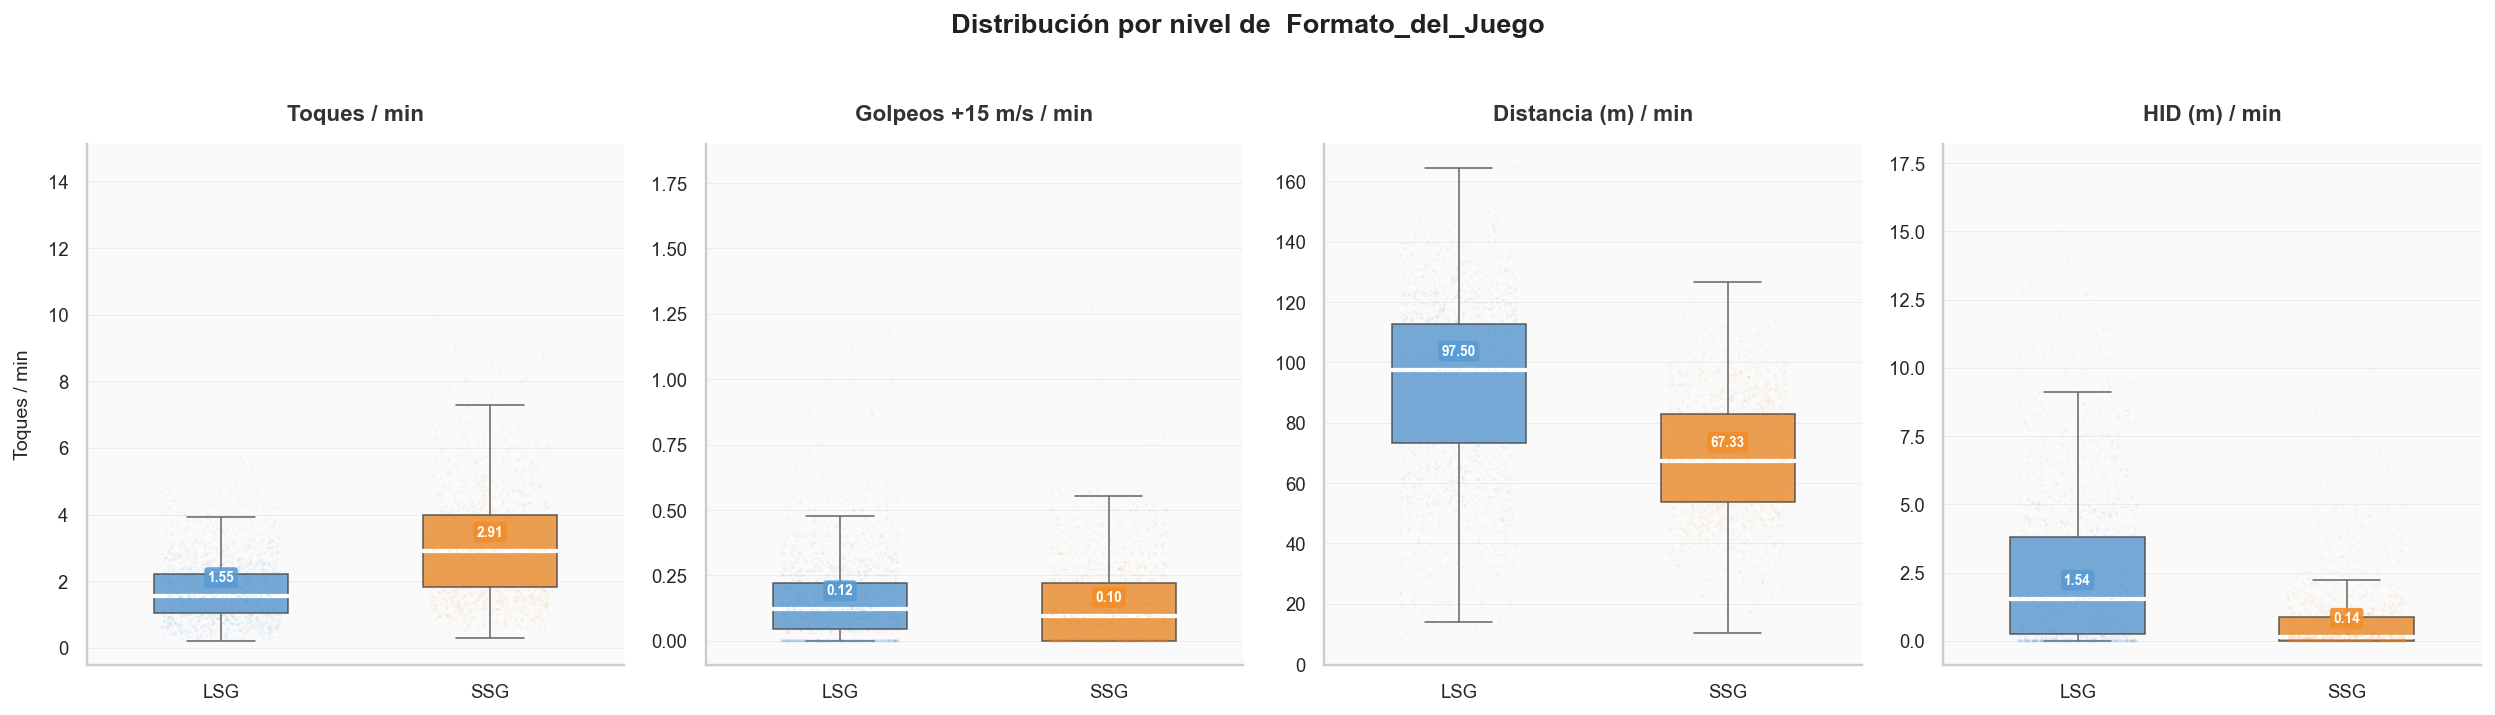

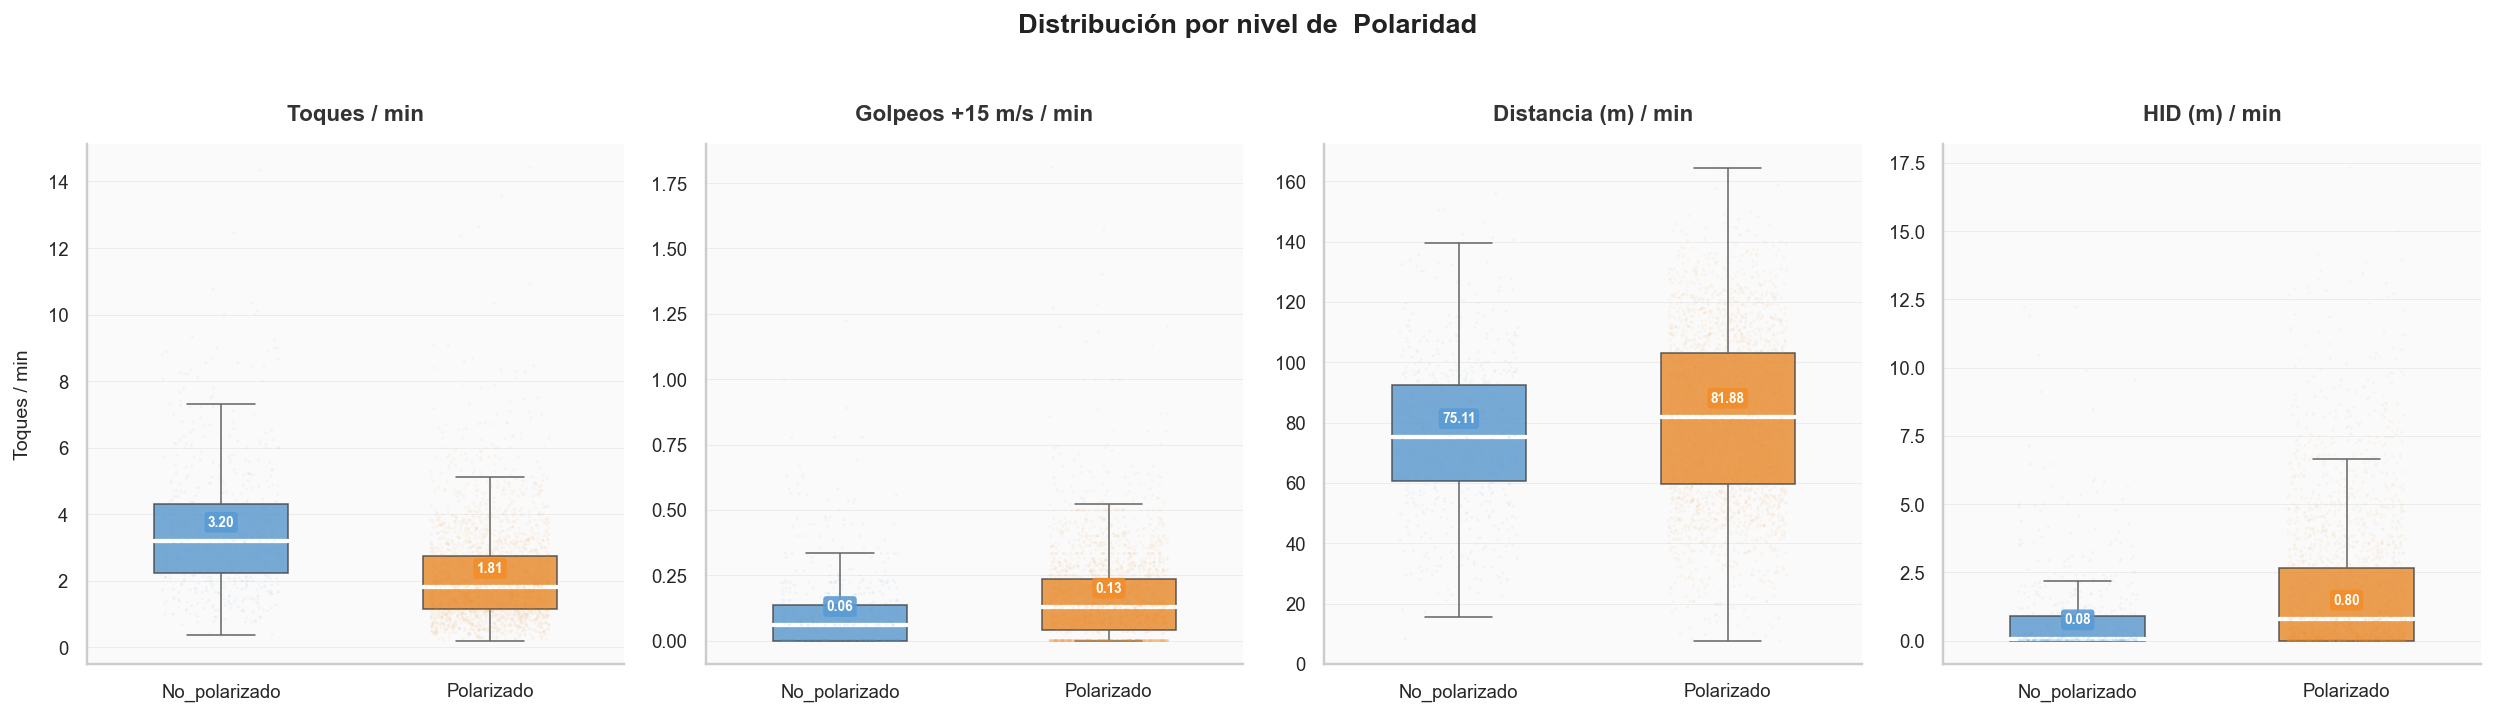

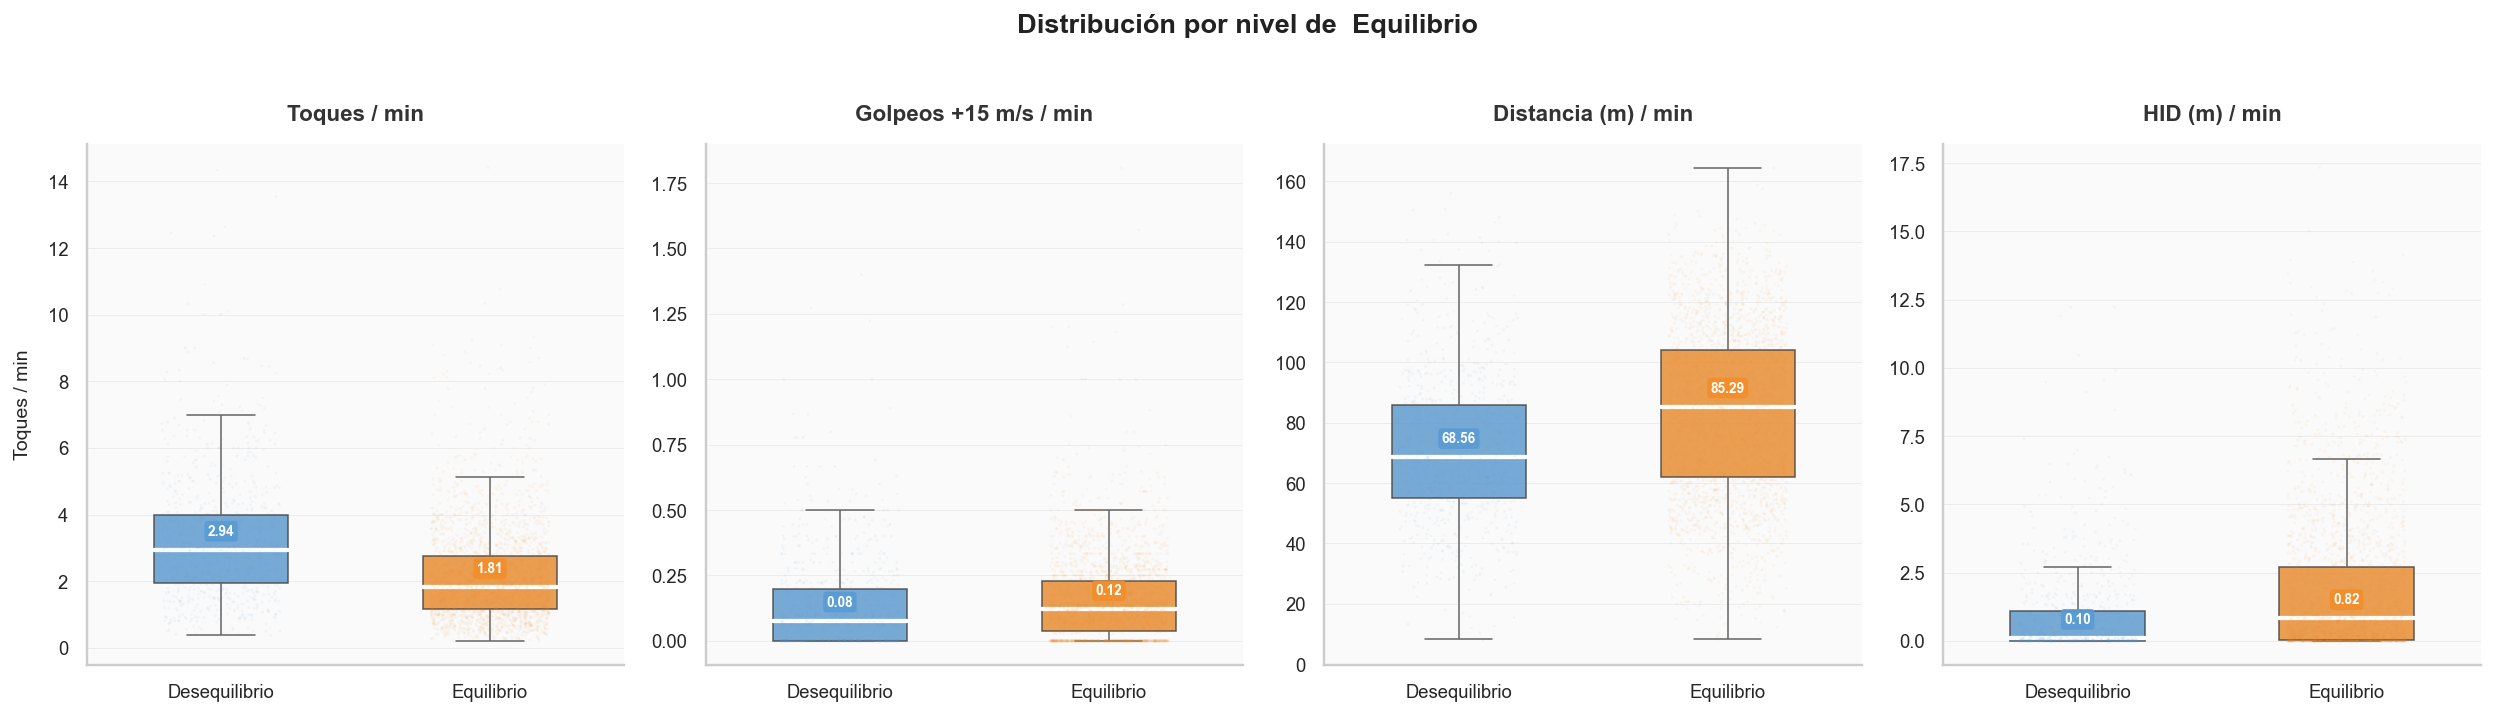

In [10]:
# ── 2a. Boxplots mejorados ────────────────────────────────
for vi in vi_cols:
    niveles = sorted(df[vi].unique())
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
        ax = axes[idx]

        # Boxplot principal
        sns.boxplot(
            data=df, x=vi, y=vd, ax=ax, order=niveles,
            palette=PAL_NIVEL, showfliers=False, width=0.50,
            linewidth=0.8, saturation=0.90,
            boxprops=dict(alpha=0.85, edgecolor="#444"),
            medianprops=dict(color="white", linewidth=2.2, solid_capstyle="round"),
            whiskerprops=dict(color="#666", linewidth=0.8),
            capprops=dict(color="#666", linewidth=0.8),
        )

        # Puntos individuales con color emparejado
        sns.stripplot(
            data=df, x=vi, y=vd, ax=ax, order=niveles,
            palette=PAL_NIVEL, alpha=0.06, size=1.5,
            jitter=0.22, edgecolor="none", dodge=False,
        )

        # Anotar medianas
        for j, nivel in enumerate(niveles):
            med = df.loc[df[vi] == nivel, vd].median()
            ax.annotate(
                f"{med:.2f}", xy=(j, med),
                fontsize=7, ha="center", va="bottom",
                fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.25", fc=PAL_NIVEL[j],
                          alpha=0.90, ec="none"),
                xytext=(0, 6), textcoords="offset points",
            )

        ax.set_title(label, fontsize=11.5, fontweight="bold", color="#333")
        ax.set_xlabel("")
        ax.set_ylabel(label if idx == 0 else "", fontsize=10)

    fig.suptitle(
        f"Distribución por nivel de  {vi}",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

### 2b. Violin plots

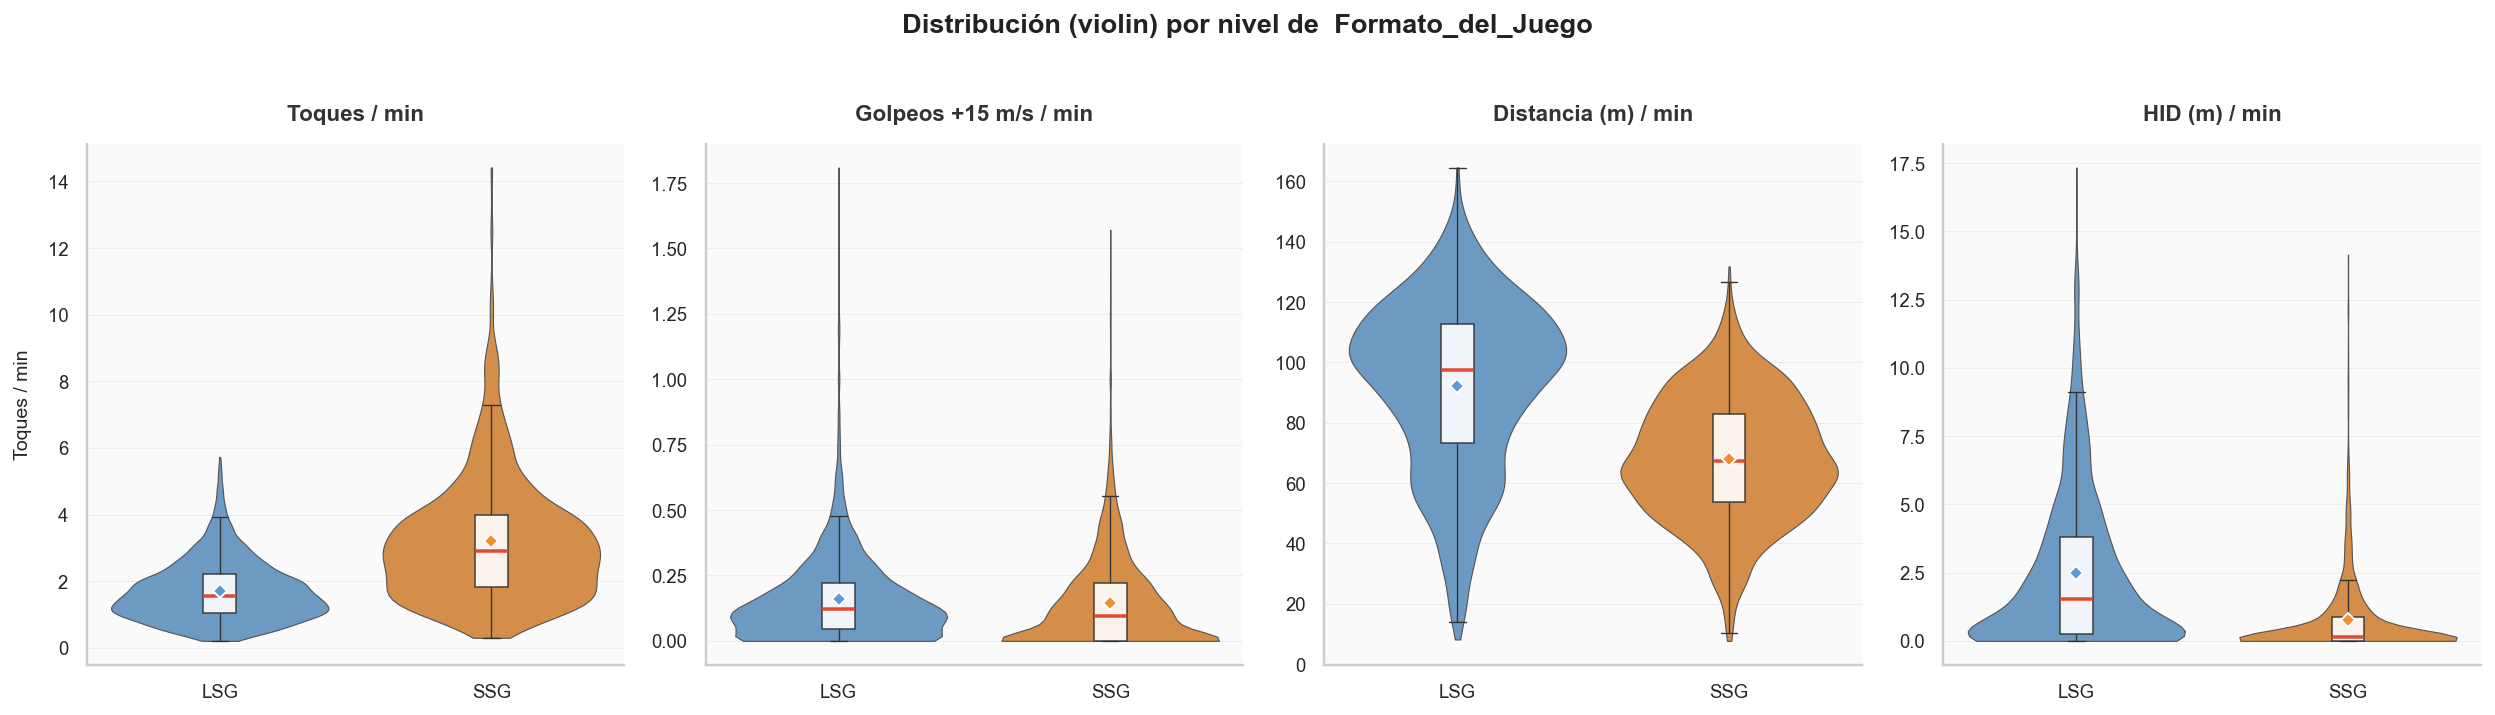

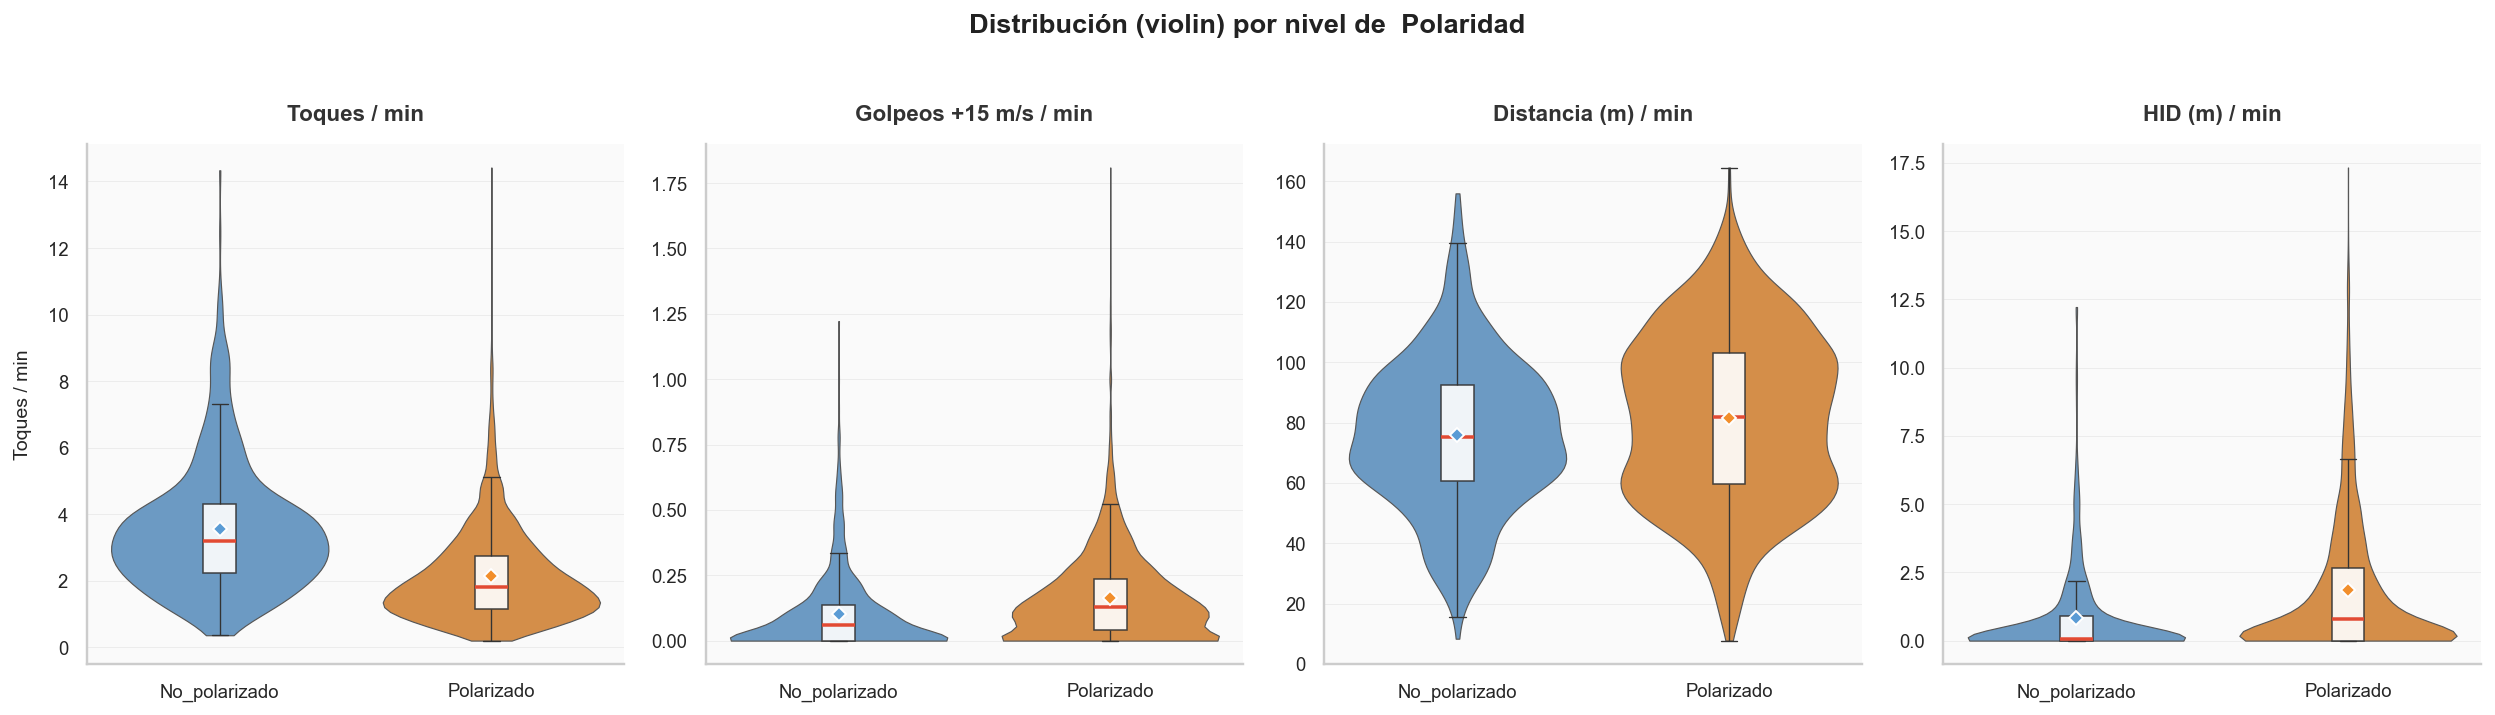

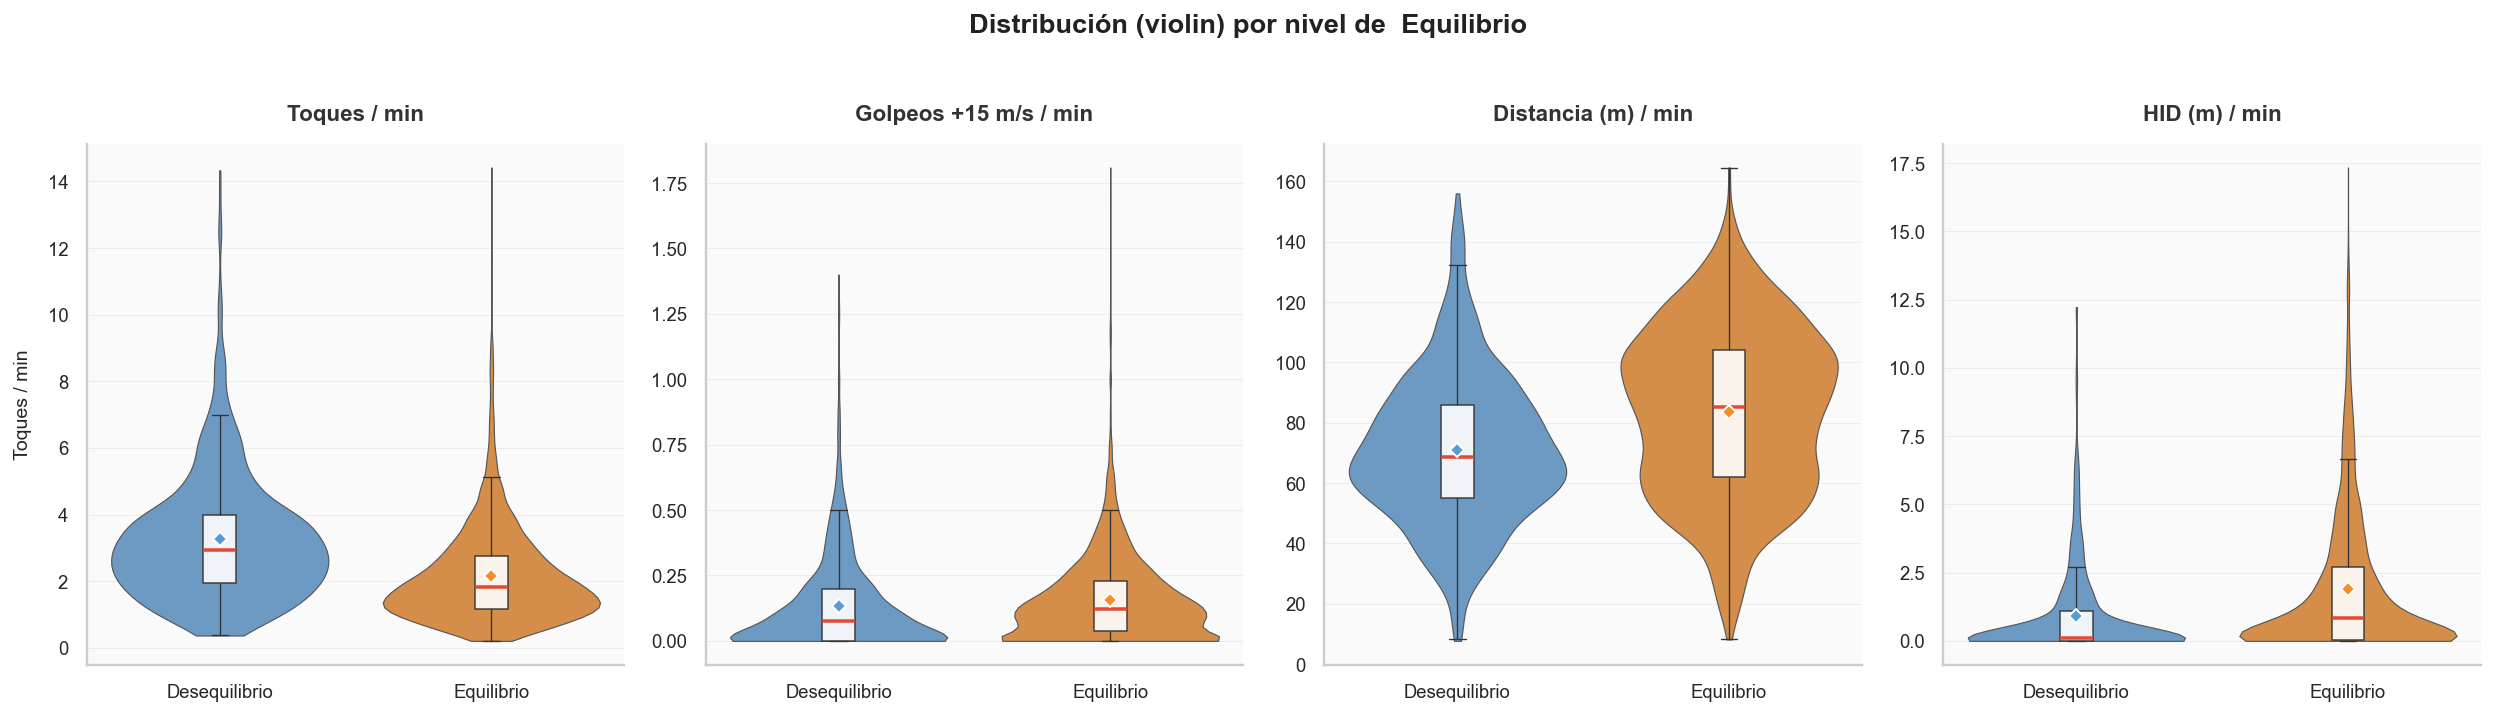

In [11]:
# ── 2b. Violin plots con mini-boxplot interior ───────────
for vi in vi_cols:
    niveles = sorted(df[vi].unique())
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
        ax = axes[idx]

        # Violin exterior (sin interior por defecto)
        sns.violinplot(
            data=df, x=vi, y=vd, ax=ax, order=niveles,
            palette=PAL_NIVEL, inner=None, linewidth=0.6,
            cut=0, saturation=0.70, bw_adjust=0.9,
        )

        # Mini-boxplot interior superpuesto
        sns.boxplot(
            data=df, x=vi, y=vd, ax=ax, order=niveles,
            width=0.12, showfliers=False,
            boxprops=dict(facecolor="white", edgecolor="#333",
                          linewidth=0.8, alpha=0.90, zorder=3),
            medianprops=dict(color="#E24A33", linewidth=1.8, zorder=4),
            whiskerprops=dict(color="#333", linewidth=0.7, zorder=3),
            capprops=dict(color="#333", linewidth=0.7, zorder=3),
        )

        # Diamante para la media
        for j, nivel in enumerate(niveles):
            media = df.loc[df[vi] == nivel, vd].mean()
            ax.plot(
                j, media, marker="D", color=PAL_NIVEL[j],
                markersize=5, markeredgecolor="white",
                markeredgewidth=1.0, zorder=5,
            )

        ax.set_title(label, fontsize=11.5, fontweight="bold", color="#333")
        ax.set_xlabel("")
        ax.set_ylabel(label if idx == 0 else "", fontsize=10)

    fig.suptitle(
        f"Distribución (violin) por nivel de  {vi}",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

### 2c. Barplots de medias con IC 95%

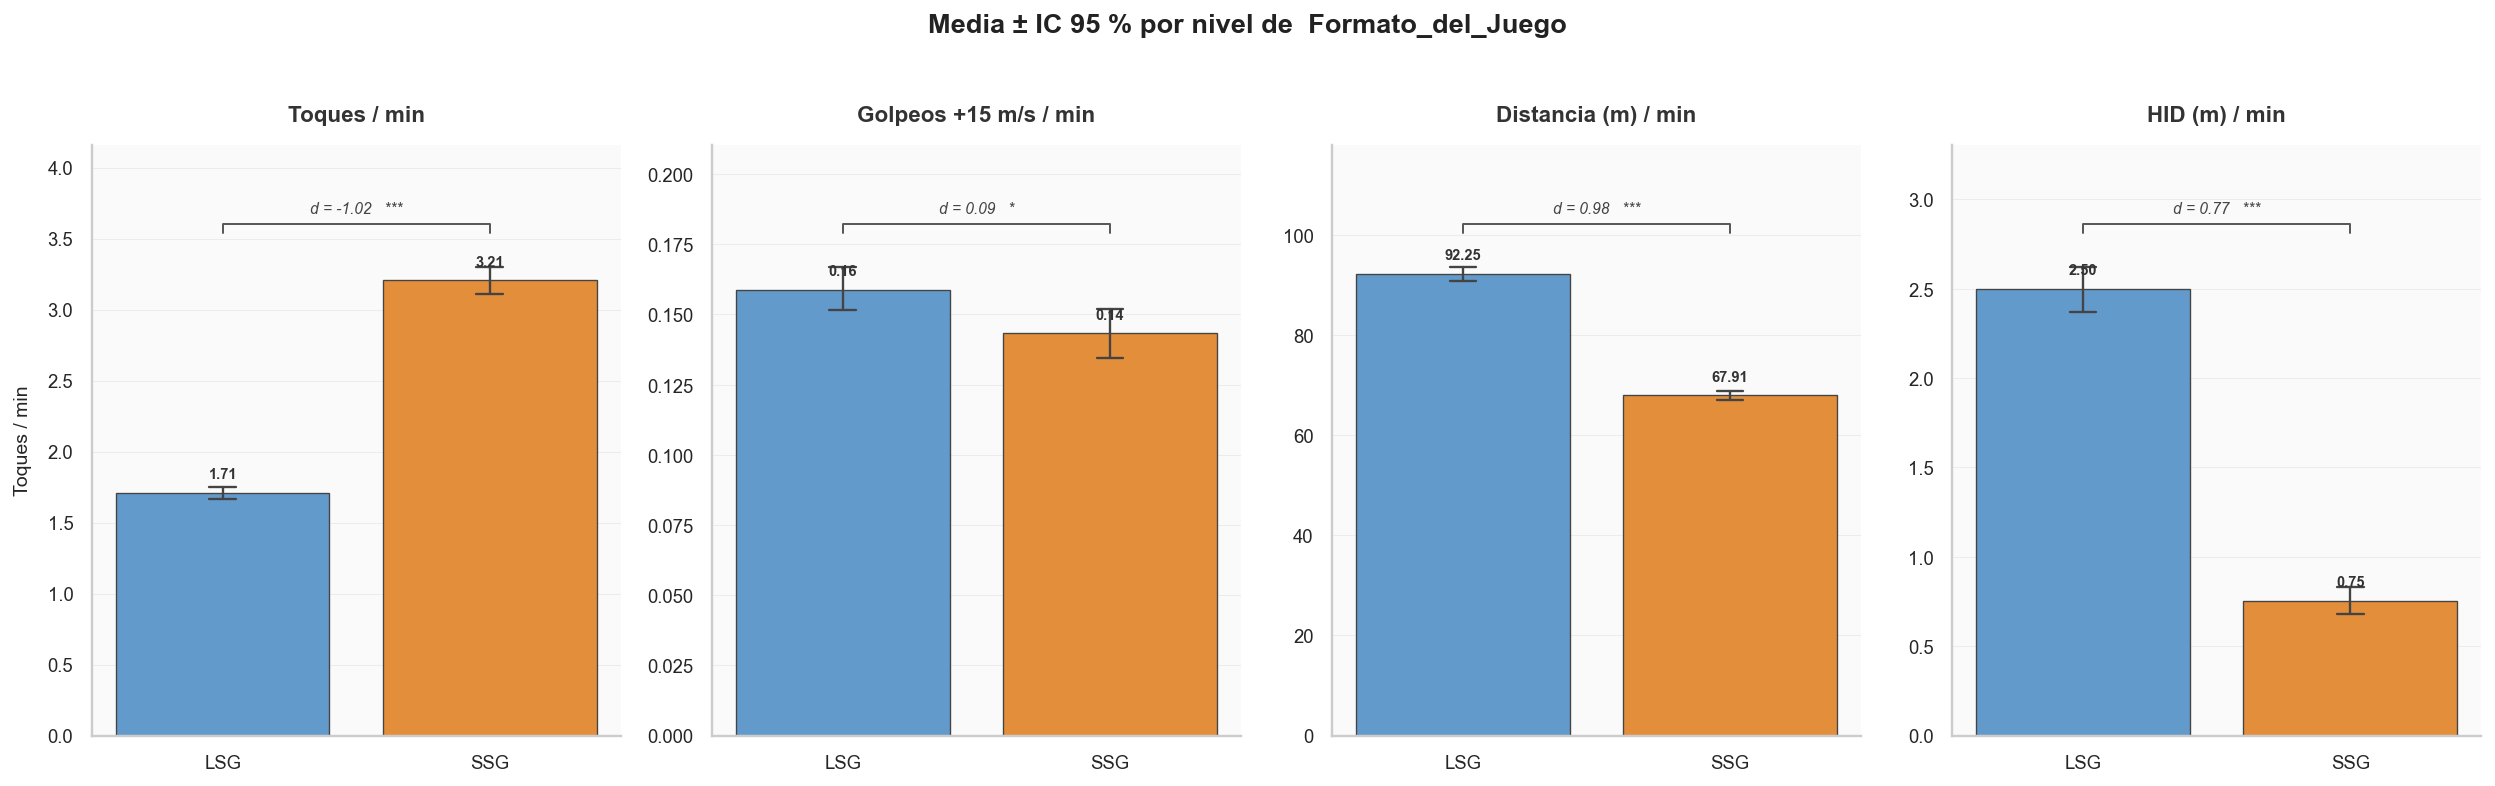

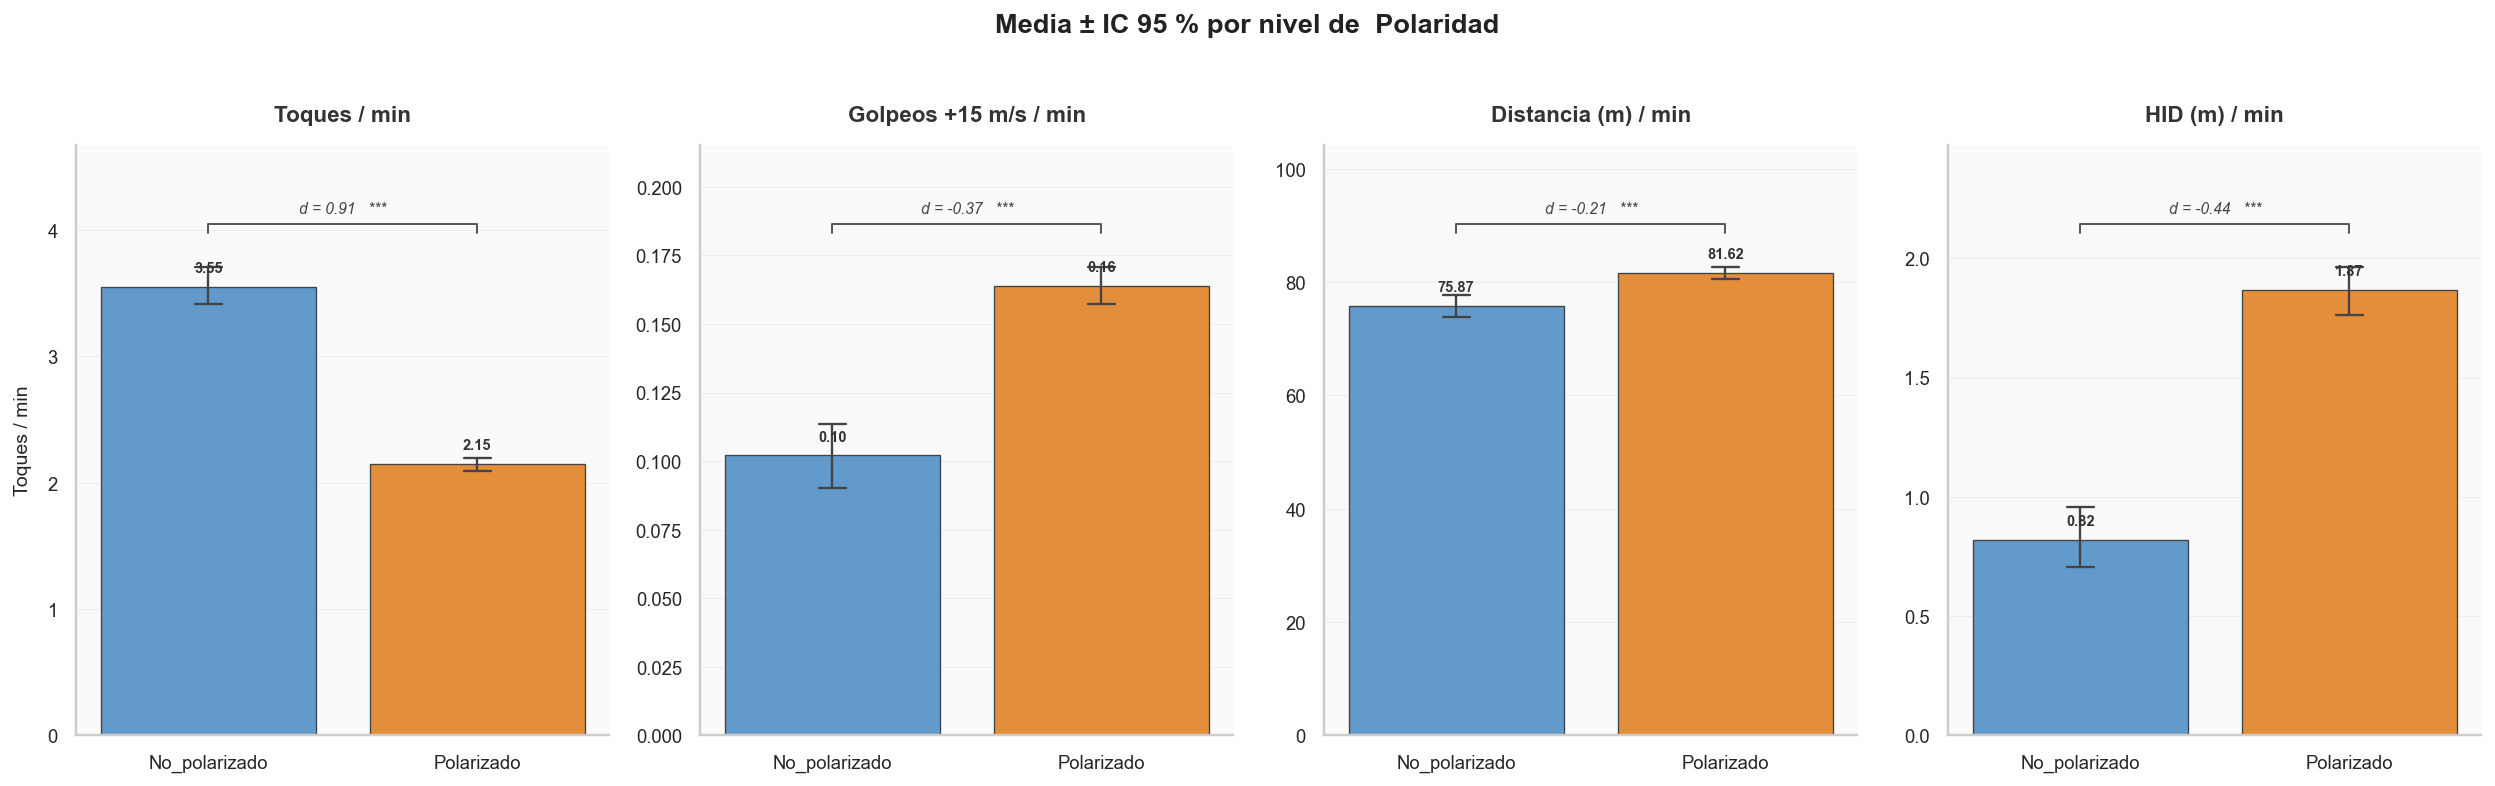

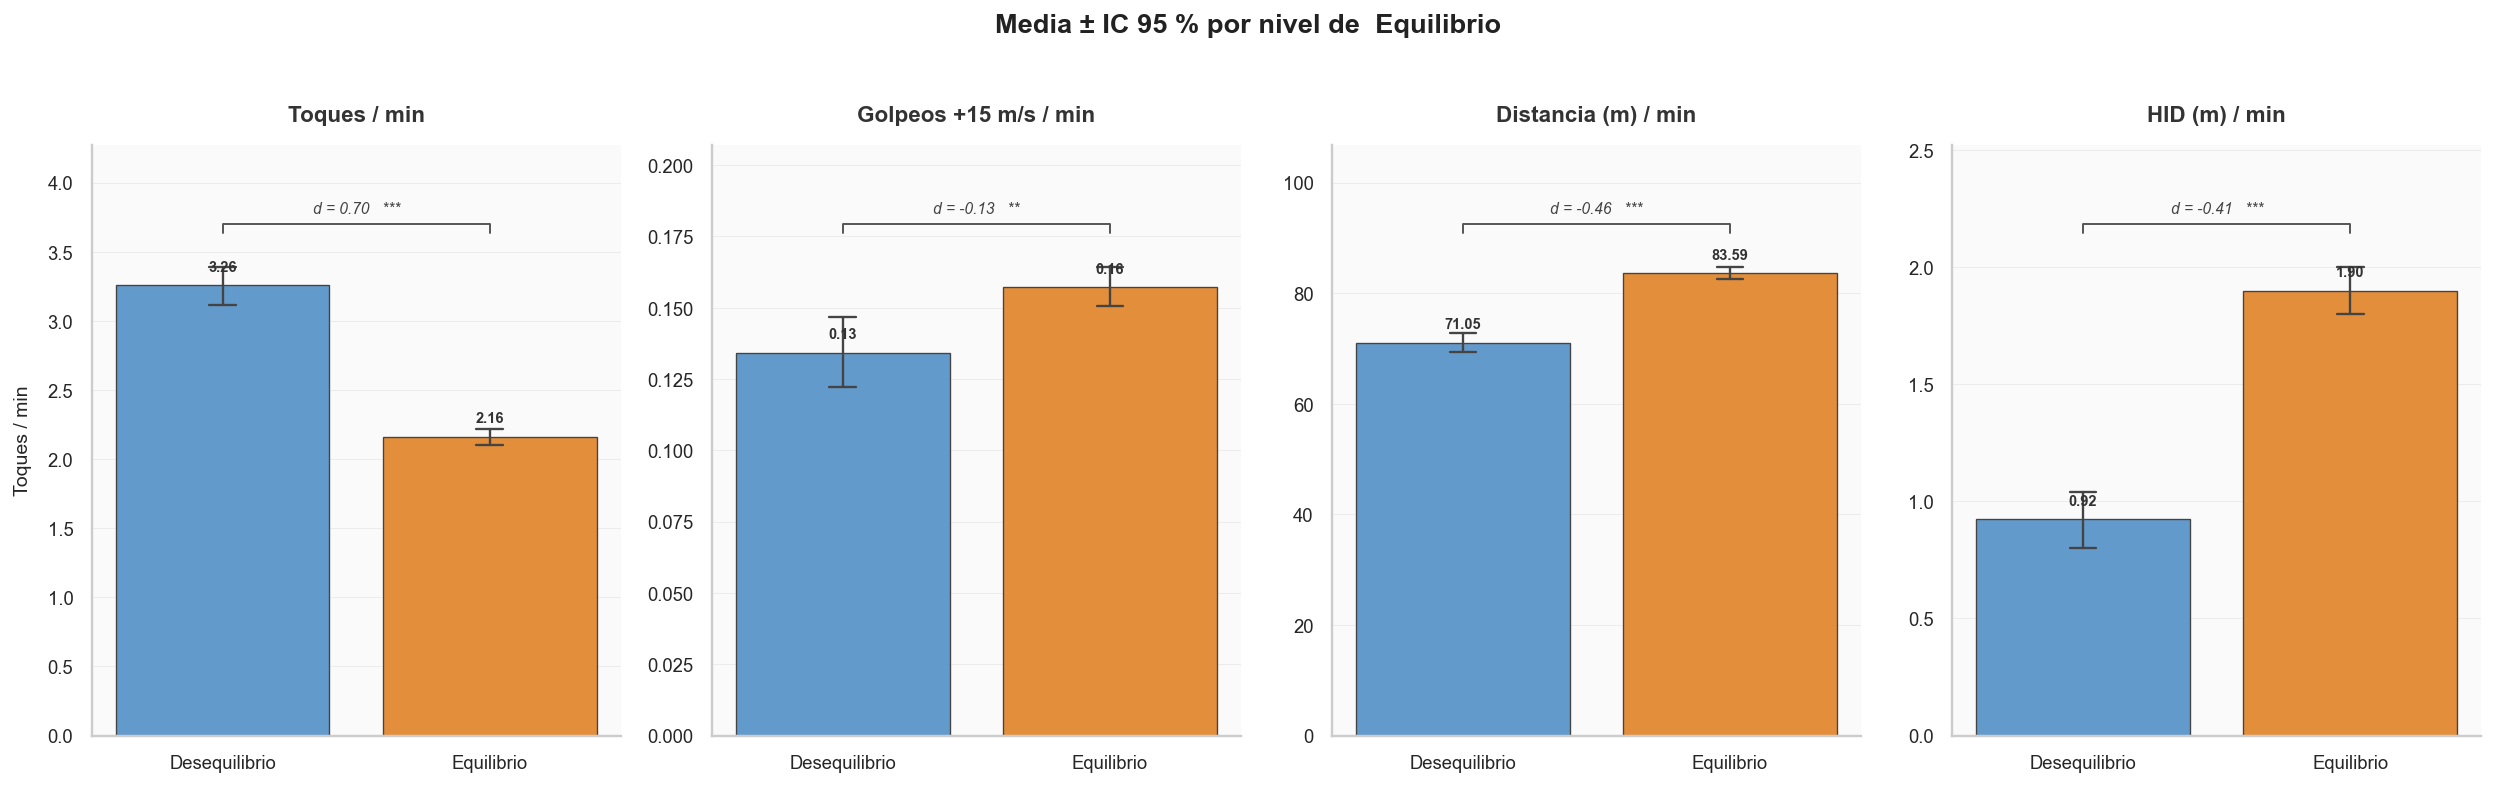

In [12]:
# ── 2c. Barplots de medias con IC 95 % y bracket de significación ──

# Helpers locales para anotación rápida
def _cohen_d_rapido(g1, g2):
    """Cohen's d con varianza pooled."""
    n1, n2 = len(g1), len(g2)
    sp = np.sqrt(((n1 - 1) * g1.std()**2 + (n2 - 1) * g2.std()**2) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / sp if sp > 0 else 0.0

def _estrellas(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

for vi in vi_cols:
    niveles = sorted(df[vi].unique())
    fig, axes = plt.subplots(1, 4, figsize=(18, 5.5))

    for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
        ax = axes[idx]

        sns.barplot(
            data=df, x=vi, y=vd, ax=ax, order=niveles,
            palette=PAL_NIVEL, errorbar=("ci", 95), capsize=0.10,
            edgecolor="#444", linewidth=0.7, saturation=0.85,
            err_kws=dict(linewidth=1.2, color="#444"),
        )

        # Anotar media sobre cada barra
        for j, nivel in enumerate(niveles):
            media = df.loc[df[vi] == nivel, vd].mean()
            ax.annotate(
                f"{media:.2f}", xy=(j, media),
                fontsize=7.5, ha="center", va="bottom",
                fontweight="bold", color="#333",
                xytext=(0, 6), textcoords="offset points",
            )

        # Bracket + Cohen's d + estrellas
        g1 = df.loc[df[vi] == niveles[0], vd].dropna()
        g2 = df.loc[df[vi] == niveles[1], vd].dropna()
        _, p_welch = stats.ttest_ind(g1, g2, equal_var=False)
        d_val = _cohen_d_rapido(g1, g2)
        stars = _estrellas(p_welch)

        y_lo, y_hi = ax.get_ylim()
        y_range = y_hi - y_lo
        y_bar = y_hi + y_range * 0.02
        h = y_range * 0.02

        ax.plot(
            [0, 0, 1, 1],
            [y_bar, y_bar + h, y_bar + h, y_bar],
            lw=1.0, c="#555", clip_on=False,
        )
        ax.text(
            0.5, y_bar + h * 1.8,
            f"d = {d_val:.2f}   {stars}",
            ha="center", va="bottom", fontsize=8,
            color="#444", fontstyle="italic", clip_on=False,
        )
        ax.set_ylim(top=y_hi + y_range * 0.20)

        ax.set_title(label, fontsize=11.5, fontweight="bold", color="#333")
        ax.set_xlabel("")
        ax.set_ylabel(label if idx == 0 else "", fontsize=10)

    fig.suptitle(
        f"Media ± IC 95 % por nivel de  {vi}",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

---
## 3. Diferencia de medias e interpretación práctica

Para cada combinación VI × VD se calcula:
- **Diferencia absoluta** de medias entre niveles.
- **Diferencia porcentual** respecto al primer nivel (referencia).
- **Cohen's *d*** (diferencia estandarizada) con su interpretación.

Si una VI tuviera >2 niveles, se calcularían las comparaciones por pares.

In [13]:
# ── Diferencia de medias y Cohen's d ──────────────────────
filas_efecto = []

for vi in vi_cols:
    niveles = vi_niveles[vi]
    # Generar todos los pares de niveles
    pares = list(combinations(niveles, 2))
    
    for n1, n2 in pares:
        for vd, label in zip(vd_cols, vd_labels):
            g1 = df.loc[df[vi] == n1, vd].dropna()
            g2 = df.loc[df[vi] == n2, vd].dropna()
            m1, m2 = g1.mean(), g2.mean()
            diff = m1 - m2
            pct = (diff / m2 * 100) if m2 != 0 else np.nan
            d = cohen_d(g1, g2)
            
            filas_efecto.append({
                "VI": vi,
                "Nivel 1": n1,
                "Nivel 2": n2,
                "VD": label,
                "Media N1": round(m1, 3),
                "Media N2": round(m2, 3),
                "Δ absoluta": round(diff, 3),
                "Δ %": round(pct, 2),
                "Cohen's d": round(d, 3),
                "Efecto": interpretar_d(d),
            })

df_efectos = pd.DataFrame(filas_efecto)
print("── Tabla de diferencias de medias y tamaño del efecto ──")
df_efectos

── Tabla de diferencias de medias y tamaño del efecto ──


,VI,Nivel 1,Nivel 2,VD,Media N1,Media N2,Δ absoluta,Δ %,Cohen's d,Efecto
0,Formato_del_Juego,LSG,SSG,Toques / min,1.708,3.205,-1.497,-46.71,-1.019,Grande
1,Formato_del_Juego,LSG,SSG,Golpeos +15 m/s / min,0.159,0.143,0.016,10.86,0.091,Negligible
2,Formato_del_Juego,LSG,SSG,Distancia (m) / min,92.248,67.913,24.335,35.83,0.977,Grande
3,Formato_del_Juego,LSG,SSG,HID (m) / min,2.499,0.754,1.744,231.19,0.769,Medio
4,Polaridad,No_polarizado,Polarizado,Toques / min,3.552,2.148,1.404,65.37,0.906,Grande
5,Polaridad,No_polarizado,Polarizado,Golpeos +15 m/s / min,0.102,0.164,-0.062,-37.71,-0.367,Pequeño
6,Polaridad,No_polarizado,Polarizado,Distancia (m) / min,75.870,81.617,-5.747,-7.04,-0.208,Pequeño
7,Polaridad,No_polarizado,Polarizado,HID (m) / min,0.818,1.867,-1.049,-56.18,-0.438,Pequeño
8,Equilibrio,Desequilibrio,Equilibrio,Toques / min,3.257,2.159,1.098,50.86,0.695,Medio
9,Equilibrio,Desequilibrio,Equilibrio,Golpeos +15 m/s / min,0.134,0.157,-0.023,-14.56,-0.134,Negligible


---
## 4. Tests estadísticos

Para cada combinación VI × VD se reportan:
- **T-test de Welch** (no asume varianzas iguales) como test paramétrico principal.
- **Mann-Whitney U** como alternativa no paramétrica robusta.
- **Cohen's *d*** como medida del tamaño del efecto.

Si alguna VI tuviera >2 niveles, se usaría Welch ANOVA (ómnibus) + comparaciones post-hoc con corrección de Bonferroni.

In [14]:
# ── Tests estadísticos ────────────────────────────────────
filas_test = []

for vi in vi_cols:
    niveles = vi_niveles[vi]
    n_niveles = len(niveles)
    
    if n_niveles == 2:
        # ── VI binaria: t-test de Welch + Mann-Whitney ────
        n1, n2 = niveles
        for vd, label in zip(vd_cols, vd_labels):
            g1 = df.loc[df[vi] == n1, vd].dropna()
            g2 = df.loc[df[vi] == n2, vd].dropna()
            
            # Normalidad (D'Agostino-Pearson si N > 5000, Shapiro-Wilk si no)
            if len(g1) > 5000:
                _, p_norm1 = stats.normaltest(g1)
                _, p_norm2 = stats.normaltest(g2)
                test_norm = "D'Agostino-Pearson"
            else:
                _, p_norm1 = stats.shapiro(g1)
                _, p_norm2 = stats.shapiro(g2)
                test_norm = "Shapiro-Wilk"
            
            # T-test de Welch
            t_stat, p_welch = stats.ttest_ind(g1, g2, equal_var=False)
            
            # Mann-Whitney U
            u_stat, p_mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            
            # Cohen's d
            d = cohen_d(g1, g2)
            
            filas_test.append({
                "VI": vi,
                "Comparación": f"{n1} vs {n2}",
                "VD": label,
                "Test norm.": test_norm,
                "p-norm N1": f"{p_norm1:.2e}",
                "p-norm N2": f"{p_norm2:.2e}",
                "t Welch": round(t_stat, 3),
                "p Welch": f"{p_welch:.2e}" if p_welch < 0.001 else round(p_welch, 4),
                "U Mann-Whitney": round(u_stat, 0),
                "p MW": f"{p_mw:.2e}" if p_mw < 0.001 else round(p_mw, 4),
                "Cohen's d": round(d, 3),
                "Efecto": interpretar_d(d),
            })
    
    else:
        # ── VI multinivel: Welch ANOVA + post-hoc ─────────
        for vd, label in zip(vd_cols, vd_labels):
            grupos = [df.loc[df[vi] == niv, vd].dropna() for niv in niveles]
            
            # Test ómnibus: Alexander-Govern (Welch ANOVA)
            res_omni = welch_anova_manual(grupos)
            
            # Eta² (basado en ANOVA one-way estándar como aproximación)
            f_ow, p_ow = stats.f_oneway(*grupos)
            ss_between = sum(len(g) * (g.mean() - df[vd].mean())**2 for g in grupos)
            ss_total = ((df[vd].dropna() - df[vd].mean())**2).sum()
            eta2 = ss_between / ss_total
            
            filas_test.append({
                "VI": vi,
                "Comparación": "Ómnibus",
                "VD": label,
                "Test norm.": "—",
                "p-norm N1": "—",
                "p-norm N2": "—",
                "t Welch": f"AG={round(res_omni.statistic, 3)}",
                "p Welch": f"{res_omni.pvalue:.2e}" if res_omni.pvalue < 0.001 else round(res_omni.pvalue, 4),
                "U Mann-Whitney": f"η²={round(eta2, 4)}",
                "p MW": "—",
                "Cohen's d": "—",
                "Efecto": "—",
            })
            
            # Post-hoc por pares con corrección de Bonferroni
            pares = list(combinations(range(len(niveles)), 2))
            n_comparaciones = len(pares)
            for i, j in pares:
                g1, g2 = grupos[i], grupos[j]
                t_ph, p_ph = stats.ttest_ind(g1, g2, equal_var=False)
                p_bonf = min(p_ph * n_comparaciones, 1.0)
                d = cohen_d(g1, g2)
                u_ph, p_mw_ph = stats.mannwhitneyu(g1, g2, alternative="two-sided")
                
                filas_test.append({
                    "VI": vi,
                    "Comparación": f"{niveles[i]} vs {niveles[j]}",
                    "VD": label,
                    "Test norm.": "—",
                    "p-norm N1": "—",
                    "p-norm N2": "—",
                    "t Welch": round(t_ph, 3),
                    "p Welch": f"{p_bonf:.2e}" if p_bonf < 0.001 else round(p_bonf, 4),
                    "U Mann-Whitney": round(u_ph, 0),
                    "p MW": f"{p_mw_ph:.2e}" if p_mw_ph < 0.001 else round(p_mw_ph, 4),
                    "Cohen's d": round(d, 3),
                    "Efecto": interpretar_d(d),
                })

df_tests = pd.DataFrame(filas_test)
print("── Resultados de tests estadísticos ──")
df_tests

── Resultados de tests estadísticos ──


,VI,Comparación,VD,Test norm.,p-norm N1,p-norm N2,t Welch,p Welch,U Mann-Whitney,p MW,Cohen's d,Efecto
0,Formato_del_Juego,LSG vs SSG,Toques / min,Shapiro-Wilk,7.90e-25,1.77e-30,-28.175,2.33e-149,574398.0,8.64e-156,-1.019,Grande
1,Formato_del_Juego,LSG vs SSG,Golpeos +15 m/s / min,Shapiro-Wilk,1.31e-41,1.89e-40,2.574,0.0101,1387720.0,9.23e-07,0.091,Negligible
2,Formato_del_Juego,LSG vs SSG,Distancia (m) / min,Shapiro-Wilk,9.29e-17,2.28e-02,27.802,2.16e-151,1922329.0,1.01e-143,0.977,Grande
3,Formato_del_Juego,LSG vs SSG,HID (m) / min,Shapiro-Wilk,7.58e-39,5.65e-52,22.050,1.67e-98,1828332.0,6.77e-109,0.769,Medio
4,Polaridad,No_polarizado vs Polarizado,Toques / min,Shapiro-Wilk,2.81e-19,4.78e-44,17.296,1.48e-57,1229631.0,1.86e-85,0.906,Grande
5,Polaridad,No_polarizado vs Polarizado,Golpeos +15 m/s / min,Shapiro-Wilk,7.75e-33,2.04e-47,-8.865,3.06e-18,581848.0,4.88e-31,-0.367,Pequeño
6,Polaridad,No_polarizado vs Polarizado,Distancia (m) / min,Shapiro-Wilk,5.27e-02,3.79e-11,-5.088,4.25e-07,722126.0,2.15e-06,-0.208,Pequeño
7,Polaridad,No_polarizado vs Polarizado,HID (m) / min,Shapiro-Wilk,9.69e-38,2.88e-52,-12.677,4.43e-35,562705.0,4.58e-36,-0.438,Pequeño
8,Equilibrio,Desequilibrio vs Equilibrio,Toques / min,Shapiro-Wilk,3.53e-23,2.23e-42,14.735,5.13e-45,1325584.0,7.01e-63,0.695,Medio
9,Equilibrio,Desequilibrio vs Equilibrio,Golpeos +15 m/s / min,Shapiro-Wilk,1.30e-33,2.34e-46,-3.131,0.0018,804216.0,5.15e-11,-0.134,Negligible


---
## 5. Tabla-resumen final consolidada

Tabla única con toda la información necesaria para cada combinación VI × VD.

In [15]:
# ── Tabla-resumen final consolidada ───────────────────────
filas_resumen = []

for vi in vi_cols:
    niveles = vi_niveles[vi]
    pares = list(combinations(niveles, 2))
    
    for n1, n2 in pares:
        for vd, label in zip(vd_cols, vd_labels):
            g1 = df.loc[df[vi] == n1, vd].dropna()
            g2 = df.loc[df[vi] == n2, vd].dropna()
            m1, m2 = g1.mean(), g2.mean()
            diff = m1 - m2
            pct = (diff / m2 * 100) if m2 != 0 else np.nan
            d = cohen_d(g1, g2)
            
            # T-test de Welch
            _, p_welch = stats.ttest_ind(g1, g2, equal_var=False)
            # Mann-Whitney
            _, p_mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            
            sig = "Sí" if p_welch < 0.05 else "No"
            
            filas_resumen.append({
                "VI": vi,
                "Nivel 1": n1,
                "Nivel 2": n2,
                "VD": label,
                "Media N1": round(m1, 3),
                "Media N2": round(m2, 3),
                "Δ absoluta": round(diff, 3),
                "Δ %": round(pct, 2),
                "Cohen's d": round(d, 3),
                "Efecto": interpretar_d(d),
                "p Welch": f"{p_welch:.2e}" if p_welch < 0.001 else round(p_welch, 4),
                "p Mann-Whitney": f"{p_mw:.2e}" if p_mw < 0.001 else round(p_mw, 4),
                "Signif. (α=0.05)": sig,
            })

df_resumen = pd.DataFrame(filas_resumen)
print("── TABLA-RESUMEN FINAL ──")
df_resumen

── TABLA-RESUMEN FINAL ──


,VI,Nivel 1,Nivel 2,VD,Media N1,Media N2,Δ absoluta,Δ %,Cohen's d,Efecto,p Welch,p Mann-Whitney,Signif. (α=0.05)
0,Formato_del_Juego,LSG,SSG,Toques / min,1.708,3.205,-1.497,-46.71,-1.019,Grande,2.33e-149,8.64e-156,Sí
1,Formato_del_Juego,LSG,SSG,Golpeos +15 m/s / min,0.159,0.143,0.016,10.86,0.091,Negligible,0.0101,9.23e-07,Sí
2,Formato_del_Juego,LSG,SSG,Distancia (m) / min,92.248,67.913,24.335,35.83,0.977,Grande,2.16e-151,1.01e-143,Sí
3,Formato_del_Juego,LSG,SSG,HID (m) / min,2.499,0.754,1.744,231.19,0.769,Medio,1.67e-98,6.77e-109,Sí
4,Polaridad,No_polarizado,Polarizado,Toques / min,3.552,2.148,1.404,65.37,0.906,Grande,1.48e-57,1.86e-85,Sí
5,Polaridad,No_polarizado,Polarizado,Golpeos +15 m/s / min,0.102,0.164,-0.062,-37.71,-0.367,Pequeño,3.06e-18,4.88e-31,Sí
6,Polaridad,No_polarizado,Polarizado,Distancia (m) / min,75.870,81.617,-5.747,-7.04,-0.208,Pequeño,4.25e-07,2.15e-06,Sí
7,Polaridad,No_polarizado,Polarizado,HID (m) / min,0.818,1.867,-1.049,-56.18,-0.438,Pequeño,4.43e-35,4.58e-36,Sí
8,Equilibrio,Desequilibrio,Equilibrio,Toques / min,3.257,2.159,1.098,50.86,0.695,Medio,5.13e-45,7.01e-63,Sí
9,Equilibrio,Desequilibrio,Equilibrio,Golpeos +15 m/s / min,0.134,0.157,-0.023,-14.56,-0.134,Negligible,0.0018,5.15e-11,Sí


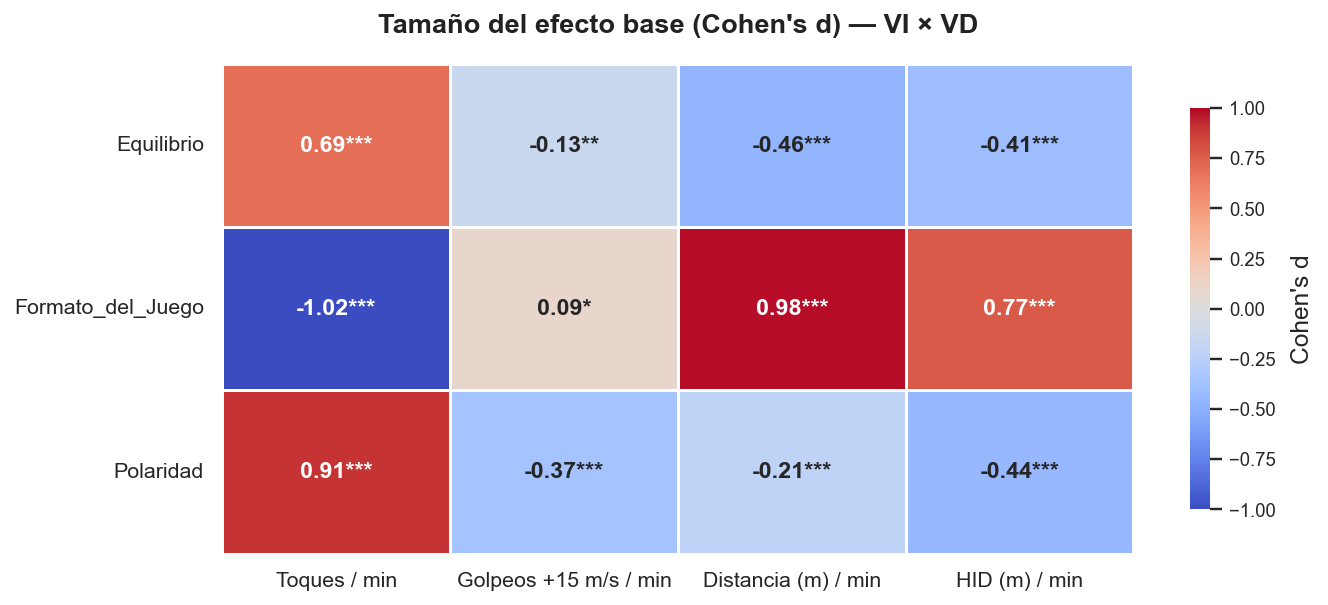

In [16]:
# ── Heatmap: Cohen's d por VI × VD ───────────────────────
pivot_d = df_resumen.pivot_table(
    index="VI", columns="VD", values="Cohen's d", aggfunc="first"
)[vd_labels].astype(float)

# p-valores para anotar estrellas de significación
pivot_sig = df_resumen.pivot_table(
    index="VI", columns="VD", values="p Welch", aggfunc="first"
)[vd_labels].astype(float)

# Anotaciones: d + estrellas
def _fmt_d_stars(d, p):
    s = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    return f"{d:.2f}{s}"

annot_d = pd.DataFrame("", index=pivot_d.index, columns=pivot_d.columns)
for vi_name in pivot_d.index:
    for vd_name in pivot_d.columns:
        annot_d.loc[vi_name, vd_name] = _fmt_d_stars(
            pivot_d.loc[vi_name, vd_name],
            pivot_sig.loc[vi_name, vd_name],
        )

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(
    pivot_d, annot=annot_d, fmt="", cmap="coolwarm",
    center=0, linewidths=1.5, linecolor="white", ax=ax,
    vmin=-1.0, vmax=1.0,
    cbar_kws={"label": "Cohen's d", "shrink": 0.82},
    annot_kws={"fontsize": 12, "fontweight": "bold"},
)
ax.set_title(
    "Tamaño del efecto base (Cohen's d) — VI × VD",
    fontsize=14, fontweight="bold", color="#222", pad=16,
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(labelsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.show()

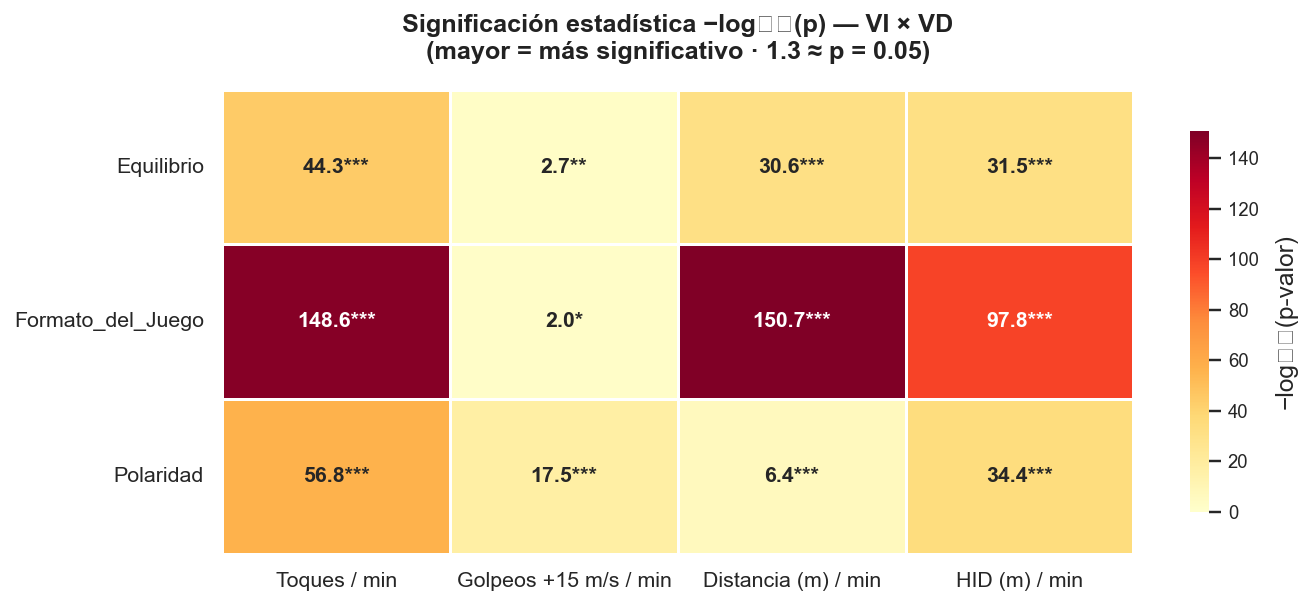

In [17]:
# ── Heatmap: −log₁₀(p) por VI × VD ──────────────────────
df_resumen_num = df_resumen.copy()
df_resumen_num["p_num"] = df_resumen_num["p Welch"].apply(
    lambda x: float(x) if isinstance(x, (int, float)) else float(x)
)
df_resumen_num["-log10(p)"] = -np.log10(df_resumen_num["p_num"].clip(lower=1e-300))

pivot_p = df_resumen_num.pivot_table(
    index="VI", columns="VD", values="-log10(p)", aggfunc="first"
)[vd_labels]

# Anotaciones: valor + estrellas
annot_p = pd.DataFrame("", index=pivot_p.index, columns=pivot_p.columns)
for vi_name in pivot_p.index:
    for vd_name in pivot_p.columns:
        val = pivot_p.loc[vi_name, vd_name]
        p_orig = 10 ** (-val)
        s = "***" if p_orig < 0.001 else ("**" if p_orig < 0.01 else ("*" if p_orig < 0.05 else " (ns)"))
        annot_p.loc[vi_name, vd_name] = f"{val:.1f}{s}"

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(
    pivot_p, annot=annot_p, fmt="", cmap="YlOrRd",
    linewidths=1.5, linecolor="white", ax=ax, vmin=0,
    cbar_kws={"label": "−log₁₀(p-valor)", "shrink": 0.82},
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)
ax.set_title(
    "Significación estadística −log₁₀(p) — VI × VD\n"
    "(mayor = más significativo · 1.3 ≈ p = 0.05)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(labelsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.show()

### Interpretación global

Los heatmaps anteriores ofrecen una visión panorámica del efecto base de cada VI sobre cada VD:

- **Cohen's *d*:** Valores cercanos a 0 indican efecto negligible; valores ≥ 0.2 indican al menos un efecto pequeño. El signo indica la dirección del efecto (positivo = Nivel 1 > Nivel 2).
- **-log₁₀(p):** Valores > 1.3 corresponden a p < 0.05; valores > 3 corresponden a p < 0.001. Cuanto mayor, más evidencia contra la H₀.

**Hallazgos principales de los heatmaps:**

| VI | VD más afectada | *d* | Efecto | Dirección |
|:---|:----------------|:---:|:------:|:----------|
| **Formato_del_Juego** | Toques / min | −1.02 | Grande | SSG > LSG |
| **Formato_del_Juego** | Distancia / min | +0.98 | Grande | LSG > SSG |
| **Formato_del_Juego** | HID / min | +0.77 | Medio | LSG > SSG |
| **Polaridad** | Toques / min | +0.91 | Grande | No_polarizado > Polarizado |
| **Polaridad** | HID / min | −0.44 | Pequeño | Polarizado > No_polarizado |
| **Equilibrio** | Toques / min | +0.70 | Medio | Desequilibrio > Equilibrio |
| **Equilibrio** | Distancia / min | −0.46 | Pequeño | Equilibrio > Desequilibrio |

Las VI con mayores efectos base son las candidatas principales a efectos fijos relevantes en los GLMM. Las combinaciones con efectos negligibles a nivel marginal (Golpeos +15 m/s) podrían aún tener efectos significativos en interacción con otras VI o con GrupoEdad.

---
## 6. Conclusiones

### Efectos base más claros

A partir de la tabla-resumen y los heatmaps, se identifican las combinaciones VI × VD con efectos marginales pronunciados:

| Rango | VI × VD | Cohen's *d* | Magnitud |
|:-----:|:--------|:-----------:|:--------:|
| 1 | Formato_del_Juego → Toques/min | −1.02 | **Grande** |
| 2 | Formato_del_Juego → Distancia/min | +0.98 | **Grande** |
| 3 | Polaridad → Toques/min | +0.91 | **Grande** |
| 4 | Formato_del_Juego → HID/min | +0.77 | **Medio** |
| 5 | Equilibrio → Toques/min | +0.70 | **Medio** |
| 6 | Equilibrio → Distancia/min | −0.46 | **Pequeño** |
| 7 | Polaridad → HID/min | −0.44 | **Pequeño** |
| 8 | Equilibrio → HID/min | −0.41 | **Pequeño** |
| 9 | Polaridad → Golpeos/min | −0.37 | **Pequeño** |

**Formato_del_Juego** es la VI con el efecto marginal más potente, concentrando los tres *d* más altos. Esto es coherente con la reclasificación que combina los efectos de espacio y agrupación.

### Efectos negligibles a nivel marginal

- **Golpeos +15 m/s / min** es la VD menos sensible: *d* negligible para Formato_del_Juego (0.09) y Equilibrio (−0.13).

Esto **no descarta** que puedan emerger efectos significativos:
- En **interacciones** con otras VI (ej. Formato_del_Juego × Polaridad).
- Al **controlar por GrupoEdad** en los modelos GLMM.

### Patrones transversales

- **Toques/min** es la VD más sensible a las tres VI (|*d*| ≥ 0.70 en todos los casos).
- **Golpeos +15 m/s** es la VD menos sensible (|*d*| < 0.40 siempre).
- El **Formato_del_Juego** produce un efecto de signo opuesto en Toques (SSG > LSG) y Distancia/HID (LSG > SSG), configurando el *trade-off* técnico-físico.

### Limitaciones del análisis marginal

1. **No controla por confounders:** Cada VI se analiza de forma independiente, sin ajustar por las demás VI ni por GrupoEdad.
2. **No captura efectos aleatorios:** La variabilidad intra-jugador (documentada en NB02) no se modela aquí.

### Enlace con la fase siguiente

Los modelos GLMM de la siguiente fase incluirán **todas las VI simultáneamente**, efectos aleatorios por jugador e interacciones, permitiendo estimar los efectos **ajustados** y compararlos con los efectos base aquí documentados.

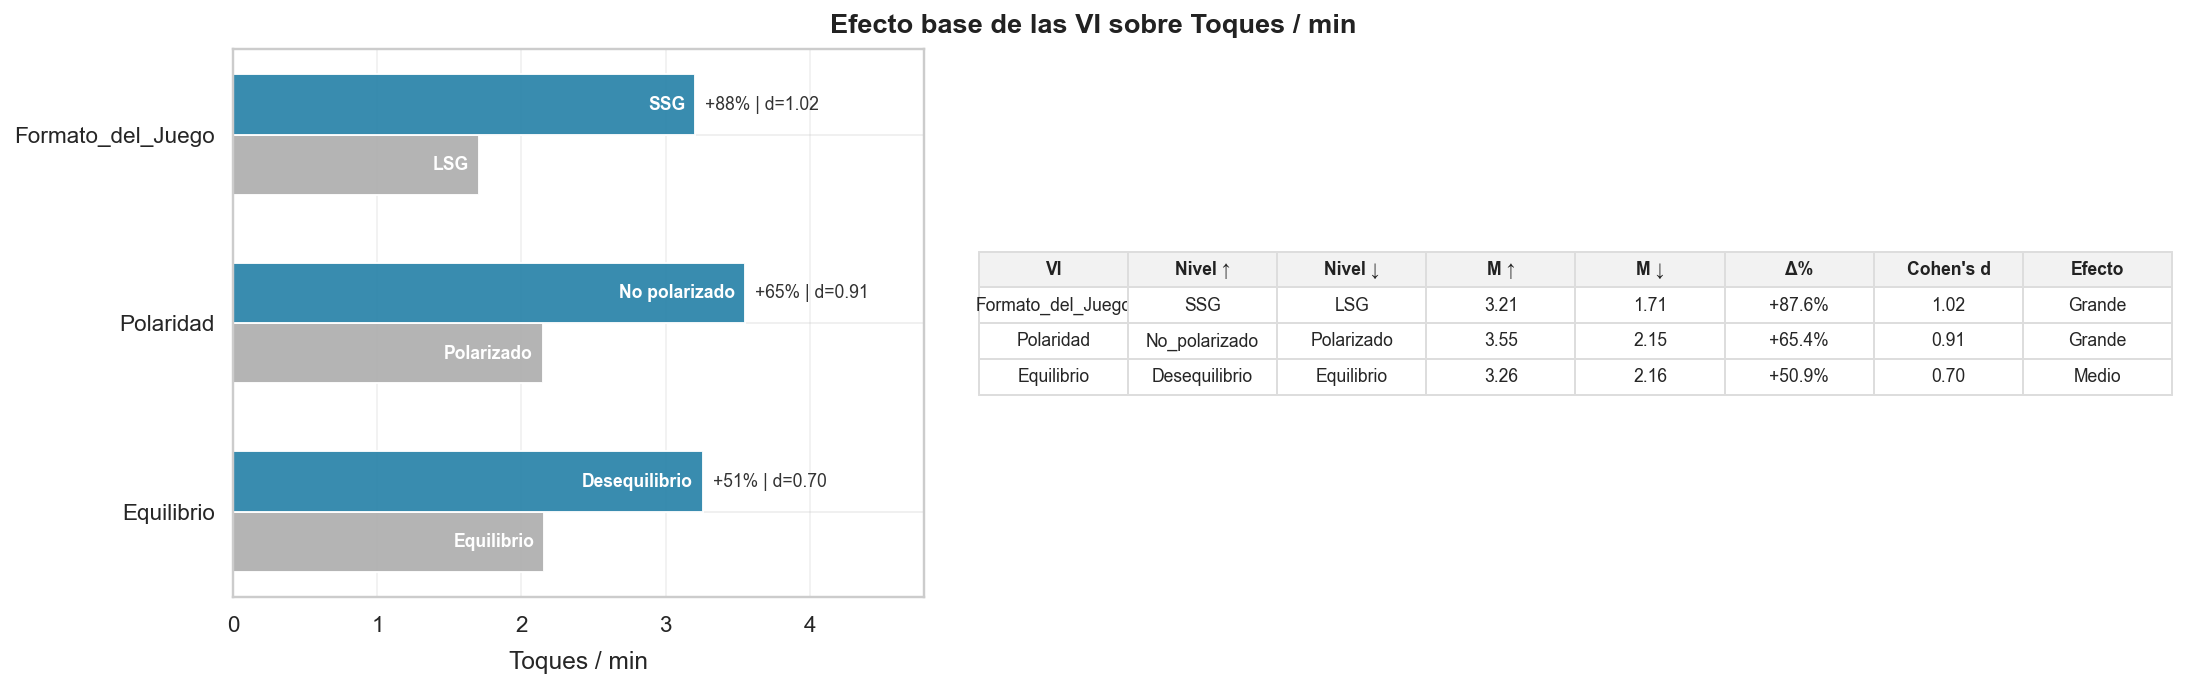

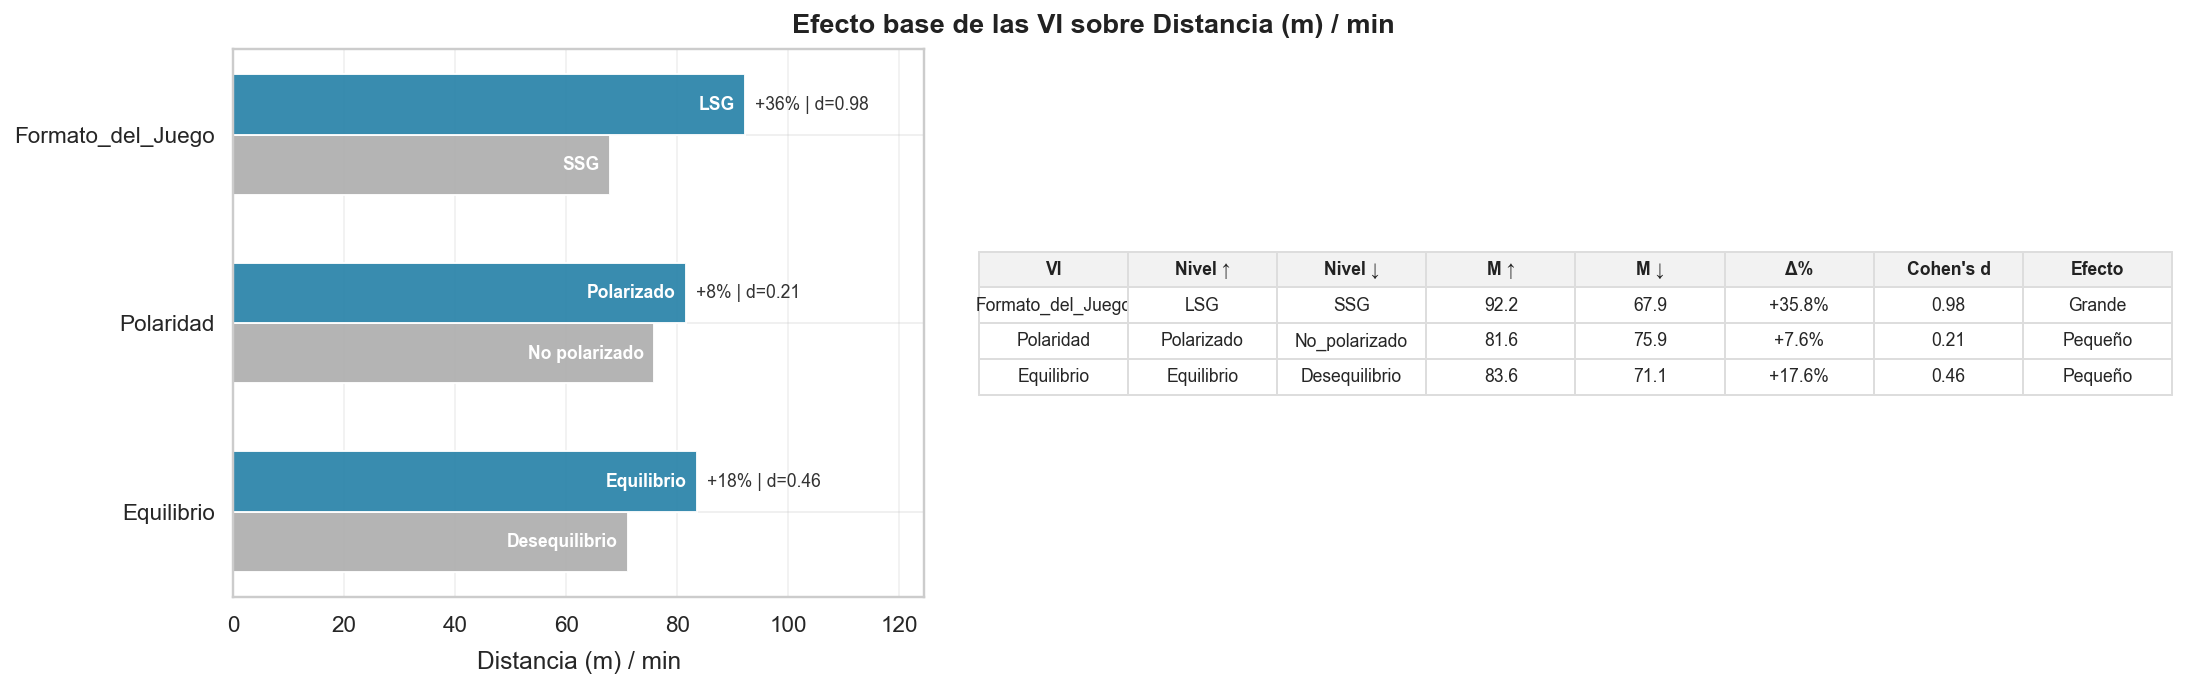

In [18]:
# ══════ Apartado nuevo (solo gráfico) — Efecto de VI sobre VD (Toques/Distancia) ══════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fallbacks para ejecutar esta celda de forma independiente
if "df" not in globals():
    df = pd.read_excel("../Datos/Matriz_V3.xlsx")

if "vi_cols" not in globals():
    vi_cols = ["Espacio", "Agrupacion", "Polaridad", "Equilibrio"]

if "vi_niveles" not in globals():
    vi_niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}

if "cohen_d" not in globals():
    def cohen_d(g1, g2):
        """Cohen's d con SD pooled."""
        n1, n2 = len(g1), len(g2)
        var1, var2 = g1.var(ddof=1), g2.var(ddof=1)
        sp = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        return (g1.mean() - g2.mean()) / sp if sp > 0 else 0.0

if "interpretar_d" not in globals():
    def interpretar_d(d):
        ad = abs(d)
        if ad < 0.2:
            return "Negligible"
        elif ad < 0.5:
            return "Pequeño"
        elif ad < 0.8:
            return "Medio"
        else:
            return "Grande"


def _tabla_efecto_binaria(df: pd.DataFrame, vd_col: str, vi_cols: list[str]) -> pd.DataFrame:
    filas = []
    for vi in vi_cols:
        niveles = vi_niveles.get(vi, sorted(df[vi].dropna().unique().tolist()))
        if len(niveles) != 2:
            continue

        n1, n2 = niveles
        g1 = df.loc[df[vi] == n1, vd_col].dropna()
        g2 = df.loc[df[vi] == n2, vd_col].dropna()

        m1, m2 = float(g1.mean()), float(g2.mean())
        if m1 >= m2:
            niv_up, niv_dn = n1, n2
            g_up, g_dn = g1, g2
            m_up, m_dn = m1, m2
        else:
            niv_up, niv_dn = n2, n1
            g_up, g_dn = g2, g1
            m_up, m_dn = m2, m1

        delta_pct = ((m_up - m_dn) / m_dn * 100.0) if m_dn != 0 else np.nan
        d = float(cohen_d(g_up, g_dn))

        filas.append({
            "VI": vi,
            "Nivel ↑": str(niv_up),
            "Nivel ↓": str(niv_dn),
            "M ↑": m_up,
            "M ↓": m_dn,
            "Δ%": delta_pct,
            "Cohen's d": d,
            "Efecto": interpretar_d(d),
        })

    # Mantener el orden original de vi_cols
    out = pd.DataFrame(filas)
    if not out.empty:
        out["_orden"] = out["VI"].apply(lambda x: vi_cols.index(x) if x in vi_cols else 999)
        out = out.sort_values("_orden").drop(columns=["_orden"]).reset_index(drop=True)
    return out


def _plot_resumen_efecto(df_eff: pd.DataFrame, titulo: str, xlabel: str, fmt_media: str = ".2f"):
    if df_eff.empty:
        return

    def _pretty_level(s: str) -> str:
        s = str(s)
        return s.replace("_", " ")

    # Diseño: barras (izq) + tabla (dcha)
    fig = plt.figure(figsize=(15.5, 4.8), layout="constrained")
    gs = fig.add_gridspec(1, 2, width_ratios=[1.10, 1.90], wspace=0.05)
    ax = fig.add_subplot(gs[0, 0])
    ax_tbl = fig.add_subplot(gs[0, 1])

    y = np.arange(len(df_eff))
    m_dn = df_eff["M ↓"].to_numpy()
    m_up = df_eff["M ↑"].to_numpy()

    # Barras horizontales (dos por VI, con pequeño desplazamiento vertical)
    h = 0.32
    y_dn = y + h / 2
    y_up = y - h / 2

    color_dn = "#B0B0B0"
    color_up = "#2E86AB"

    ax.barh(y_dn, m_dn, height=h, color=color_dn, alpha=0.95)
    ax.barh(y_up, m_up, height=h, color=color_up, alpha=0.95)

    # Etiquetas del eje Y centradas por VI
    ax.set_yticks(y)
    ax.set_yticklabels(df_eff["VI"].tolist())
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)

    # Ajuste de límites para anotaciones
    x_max = float(np.nanmax(np.r_[m_dn, m_up]))
    x_span = x_max if x_max > 0 else 1.0
    ax.set_xlim(0, x_max + 0.35 * x_span)
    x_pad = 0.02 * x_span

    # Etiquetas con el nombre del nivel en cada barra
    # (y a la derecha de la barra ↑ dejamos también Δ% y d)
    for i in range(len(df_eff)):
        lvl_dn = _pretty_level(df_eff.loc[i, "Nivel ↓"])
        lvl_up = _pretty_level(df_eff.loc[i, "Nivel ↑"])

        # Nombre del nivel ↓ dentro de la barra gris
        x_dn = max(m_dn[i] - 0.02 * x_span, 0.02 * x_span)
        ax.text(
            x_dn,
            y_dn[i],
            lvl_dn,
            va="center",
            ha="right",
            fontsize=9,
            color="white" if m_dn[i] > 0.25 * x_max else "#444",
            fontweight="bold" if m_dn[i] > 0.25 * x_max else "normal",
        )

        # Nombre del nivel ↑ dentro de la barra azul
        x_up = max(m_up[i] - 0.02 * x_span, 0.02 * x_span)
        ax.text(
            x_up,
            y_up[i],
            lvl_up,
            va="center",
            ha="right",
            fontsize=9,
            color="white" if m_up[i] > 0.25 * x_max else "#1f4f66",
            fontweight="bold" if m_up[i] > 0.25 * x_max else "normal",
        )

        # Δ% y d al final de la barra ↑
        delta = df_eff.loc[i, "Δ%"]
        d = df_eff.loc[i, "Cohen's d"]
        txt = f"+{delta:.0f}% | d={d:.2f}" if np.isfinite(delta) else f"d={d:.2f}"
        ax.text(m_up[i] + x_pad, y_up[i], txt, va="center", fontsize=9, color="#333")

    # Tabla
    ax_tbl.axis("off")

    df_tbl = df_eff.copy()
    df_tbl["M ↑"] = df_tbl["M ↑"].map(lambda v: format(v, fmt_media))
    df_tbl["M ↓"] = df_tbl["M ↓"].map(lambda v: format(v, fmt_media))
    df_tbl["Δ%"] = df_tbl["Δ%"].map(lambda v: f"+{v:.1f}%" if np.isfinite(v) else "—")
    df_tbl["Cohen's d"] = df_tbl["Cohen's d"].map(lambda v: f"{v:.2f}")

    cols = ["VI", "Nivel ↑", "Nivel ↓", "M ↑", "M ↓", "Δ%", "Cohen's d", "Efecto"]
    cell_text = df_tbl[cols].values.tolist()

    tbl = ax_tbl.table(
        cellText=cell_text,
        colLabels=cols,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.0, 1.45)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        if r == 0:
            cell.set_facecolor("#F2F2F2")
            cell.set_text_props(weight="bold", color="#222")
        else:
            cell.set_facecolor("white")

    fig.suptitle(titulo, fontsize=14, fontweight="bold", color="#222")
    plt.show()


# Ajuste estético (por si se ejecuta aislado)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

# VD objetivo
vd_targets = [
    ("Total Touches / min", "Toques / min", ".2f"),
    ("Distance Covered (m) / min", "Distancia (m) / min", ".1f"),
]

for vd_col, vd_label, fmt_media in vd_targets:
    df_eff = _tabla_efecto_binaria(df=df, vd_col=vd_col, vi_cols=vi_cols)
    _plot_resumen_efecto(
        df_eff=df_eff,
        titulo=f"Efecto base de las VI sobre {vd_label}",
        xlabel=vd_label,
        fmt_media=fmt_media,
    )


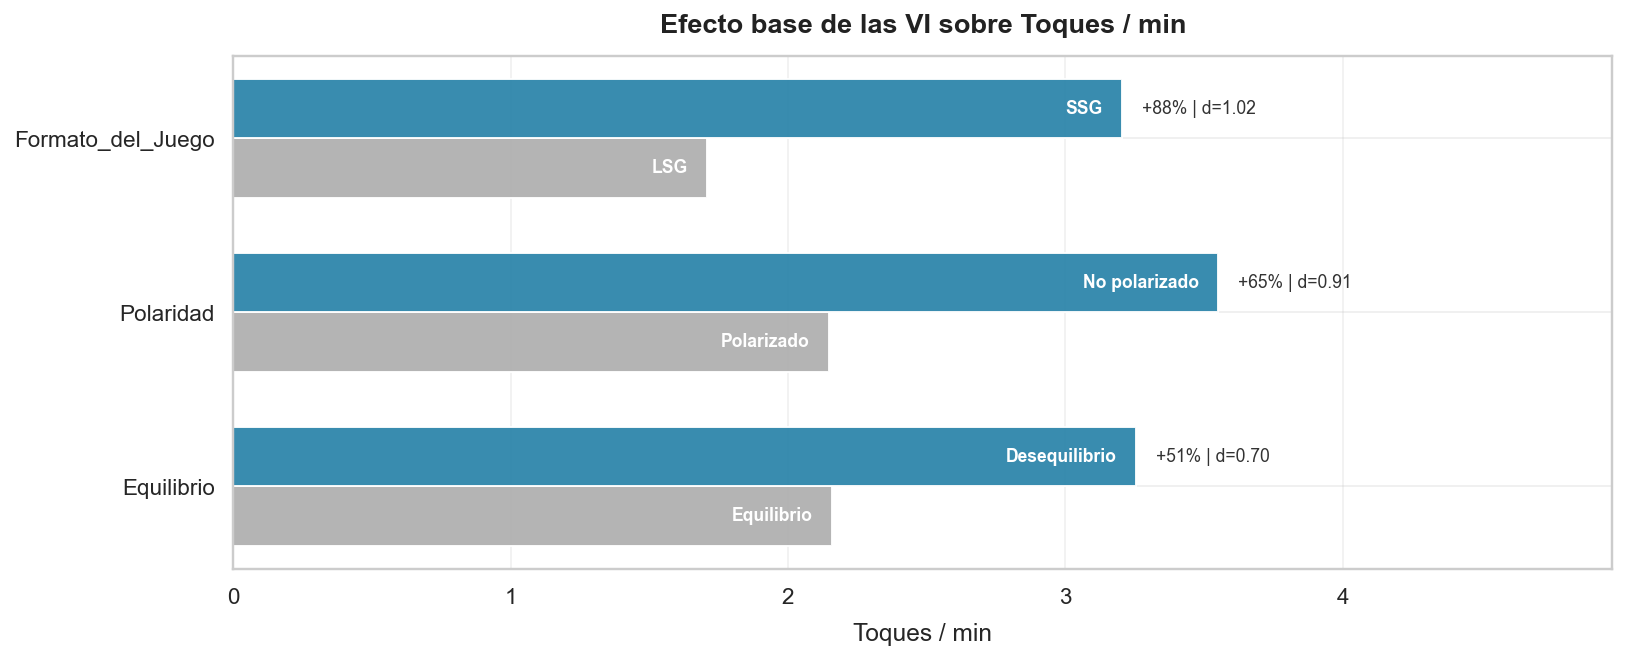

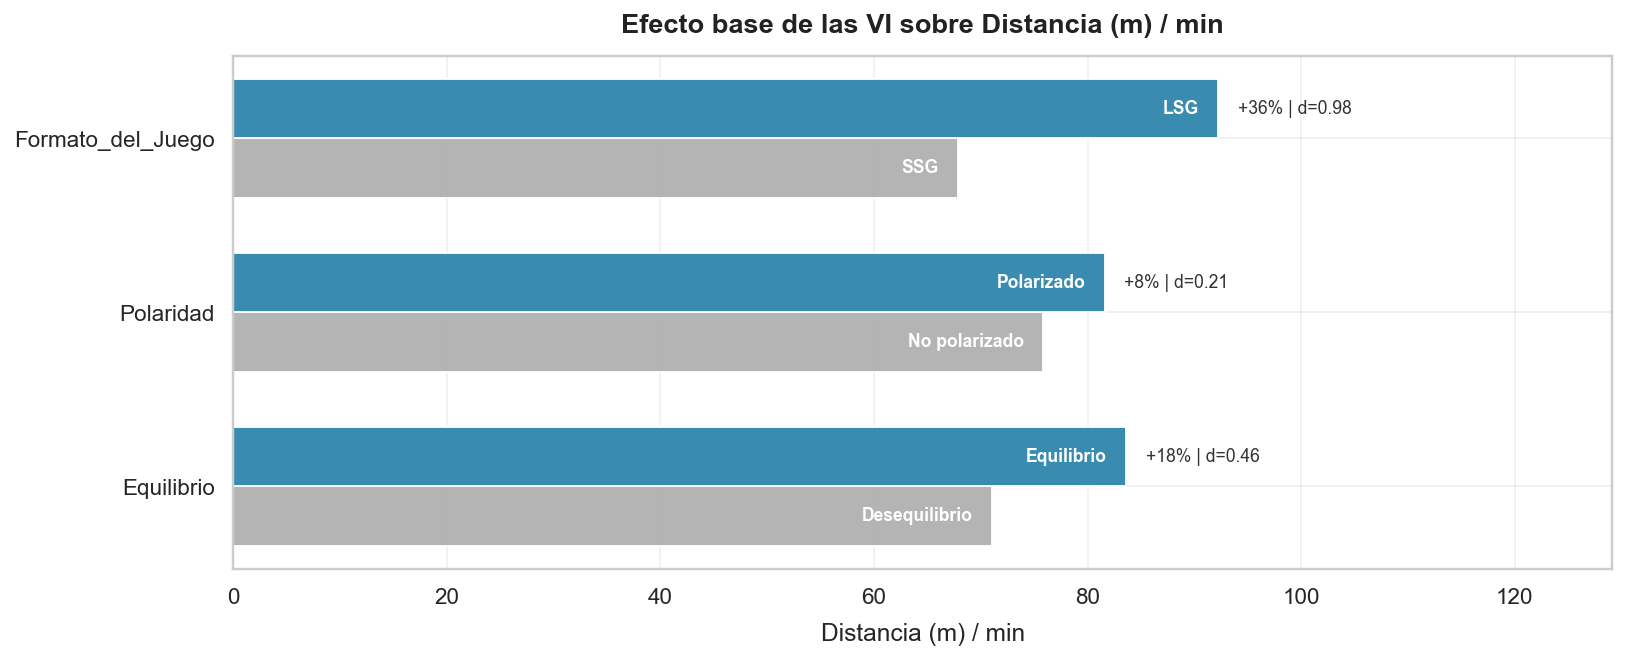

In [19]:
# ══════ Gráfico (solo barras) — Efecto base VI → VD ══════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reusa los objetos/funciones definidos en la celda anterior.
# Si se ejecuta esta celda aislada, se recrea lo mínimo para funcionar.
if "df" not in globals():
    df = pd.read_excel("../Datos/Matriz_V3.xlsx")

if "vi_cols" not in globals():
    vi_cols = ["Formato_del_Juego", "Polaridad", "Equilibrio"]

if "vi_niveles" not in globals():
    vi_niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}

if "cohen_d" not in globals():
    def cohen_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        var1, var2 = g1.var(ddof=1), g2.var(ddof=1)
        sp = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        return (g1.mean() - g2.mean()) / sp if sp > 0 else 0.0

if "interpretar_d" not in globals():
    def interpretar_d(d):
        ad = abs(d)
        if ad < 0.2:
            return "Negligible"
        elif ad < 0.5:
            return "Pequeño"
        elif ad < 0.8:
            return "Medio"
        else:
            return "Grande"

if "_tabla_efecto_binaria" not in globals():
    def _tabla_efecto_binaria(df: pd.DataFrame, vd_col: str, vi_cols: list[str]) -> pd.DataFrame:
        filas = []
        for vi in vi_cols:
            niveles = vi_niveles.get(vi, sorted(df[vi].dropna().unique().tolist()))
            if len(niveles) != 2:
                continue

            n1, n2 = niveles
            g1 = df.loc[df[vi] == n1, vd_col].dropna()
            g2 = df.loc[df[vi] == n2, vd_col].dropna()

            m1, m2 = float(g1.mean()), float(g2.mean())
            if m1 >= m2:
                niv_up, niv_dn = n1, n2
                g_up, g_dn = g1, g2
                m_up, m_dn = m1, m2
            else:
                niv_up, niv_dn = n2, n1
                g_up, g_dn = g2, g1
                m_up, m_dn = m2, m1

            delta_pct = ((m_up - m_dn) / m_dn * 100.0) if m_dn != 0 else np.nan
            d = float(cohen_d(g_up, g_dn))

            filas.append({
                "VI": vi,
                "Nivel ↑": str(niv_up),
                "Nivel ↓": str(niv_dn),
                "M ↑": m_up,
                "M ↓": m_dn,
                "Δ%": delta_pct,
                "Cohen's d": d,
                "Efecto": interpretar_d(d),
            })

        out = pd.DataFrame(filas)
        if not out.empty:
            out["_orden"] = out["VI"].apply(lambda x: vi_cols.index(x) if x in vi_cols else 999)
            out = out.sort_values("_orden").drop(columns=["_orden"]).reset_index(drop=True)
        return out


def _plot_solo_barras(df_eff: pd.DataFrame, titulo: str, xlabel: str):
    if df_eff.empty:
        return

    def _pretty_level(s: str) -> str:
        return str(s).replace("_", " ")

    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

    fig, ax = plt.subplots(figsize=(11.5, 4.6), layout="constrained")

    y = np.arange(len(df_eff))
    m_dn = df_eff["M ↓"].to_numpy()
    m_up = df_eff["M ↑"].to_numpy()

    h = 0.34
    y_dn = y + h / 2
    y_up = y - h / 2

    color_dn = "#B0B0B0"
    color_up = "#2E86AB"

    ax.barh(y_dn, m_dn, height=h, color=color_dn, alpha=0.95)
    ax.barh(y_up, m_up, height=h, color=color_up, alpha=0.95)

    ax.set_yticks(y)
    ax.set_yticklabels(df_eff["VI"].tolist())
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)

    x_max = float(np.nanmax(np.r_[m_dn, m_up]))
    x_span = x_max if x_max > 0 else 1.0
    ax.set_xlim(0, x_max + 0.40 * x_span)
    x_pad = 0.02 * x_span

    # Etiquetas de niveles dentro de barras + Δ% y d fuera
    for i in range(len(df_eff)):
        lvl_dn = _pretty_level(df_eff.loc[i, "Nivel ↓"])
        lvl_up = _pretty_level(df_eff.loc[i, "Nivel ↑"])

        x_dn = max(m_dn[i] - 0.02 * x_span, 0.02 * x_span)
        ax.text(
            x_dn,
            y_dn[i],
            lvl_dn,
            va="center",
            ha="right",
            fontsize=9,
            color="white" if m_dn[i] > 0.25 * x_max else "#444",
            fontweight="bold" if m_dn[i] > 0.25 * x_max else "normal",
        )

        x_up = max(m_up[i] - 0.02 * x_span, 0.02 * x_span)
        ax.text(
            x_up,
            y_up[i],
            lvl_up,
            va="center",
            ha="right",
            fontsize=9,
            color="white" if m_up[i] > 0.25 * x_max else "#1f4f66",
            fontweight="bold" if m_up[i] > 0.25 * x_max else "normal",
        )

        delta = df_eff.loc[i, "Δ%"]
        d = df_eff.loc[i, "Cohen's d"]
        txt = f"+{delta:.0f}% | d={d:.2f}" if np.isfinite(delta) else f"d={d:.2f}"
        ax.text(m_up[i] + x_pad, y_up[i], txt, va="center", fontsize=9, color="#333")

    ax.set_title(titulo, fontsize=14, fontweight="bold", color="#222", pad=12)
    plt.show()


vd_targets = [
    ("Total Touches / min", "Toques / min"),
    ("Distance Covered (m) / min", "Distancia (m) / min"),
]

for vd_col, vd_label in vd_targets:
    df_eff = _tabla_efecto_binaria(df=df, vd_col=vd_col, vi_cols=vi_cols)
    _plot_solo_barras(
        df_eff=df_eff,
        titulo=f"Efecto base de las VI sobre {vd_label}",
        xlabel=vd_label,
    )

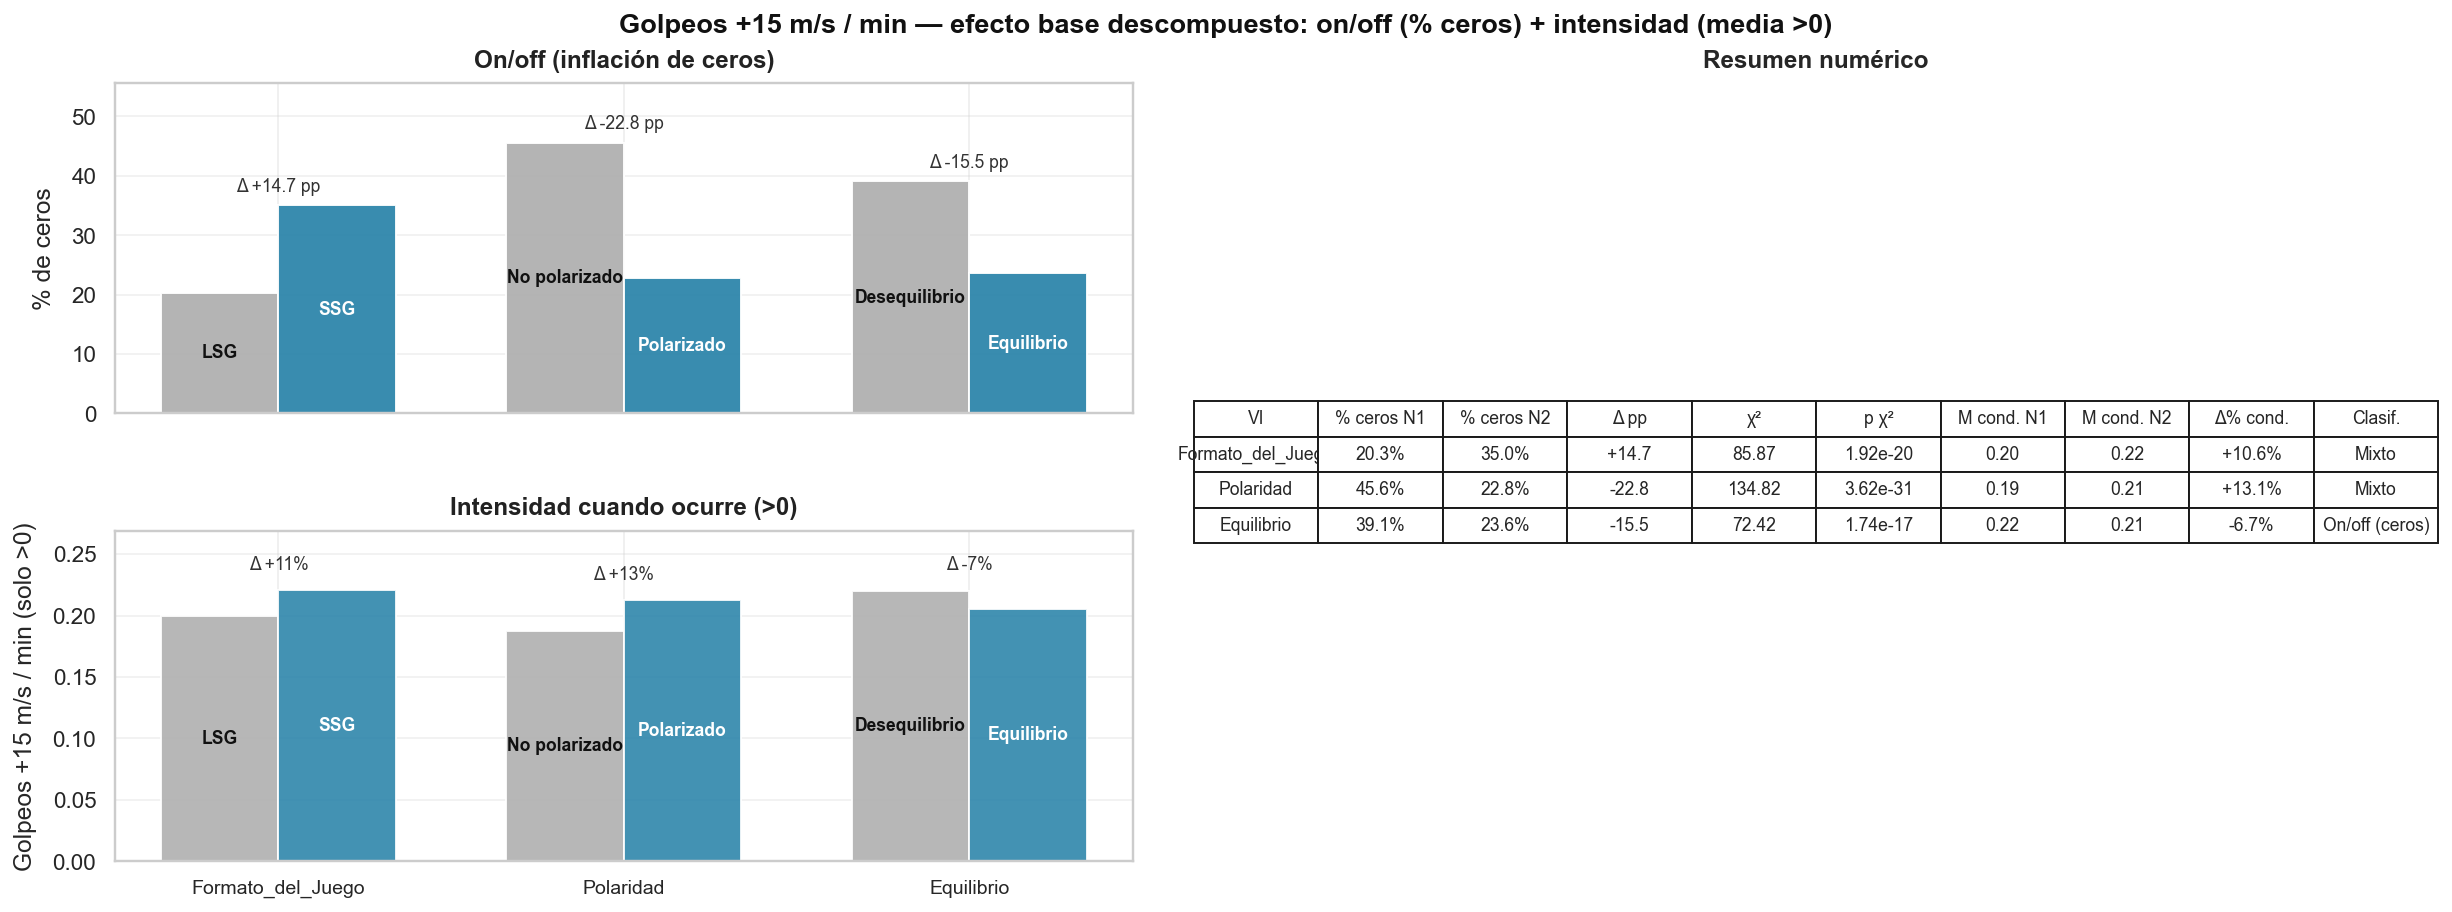

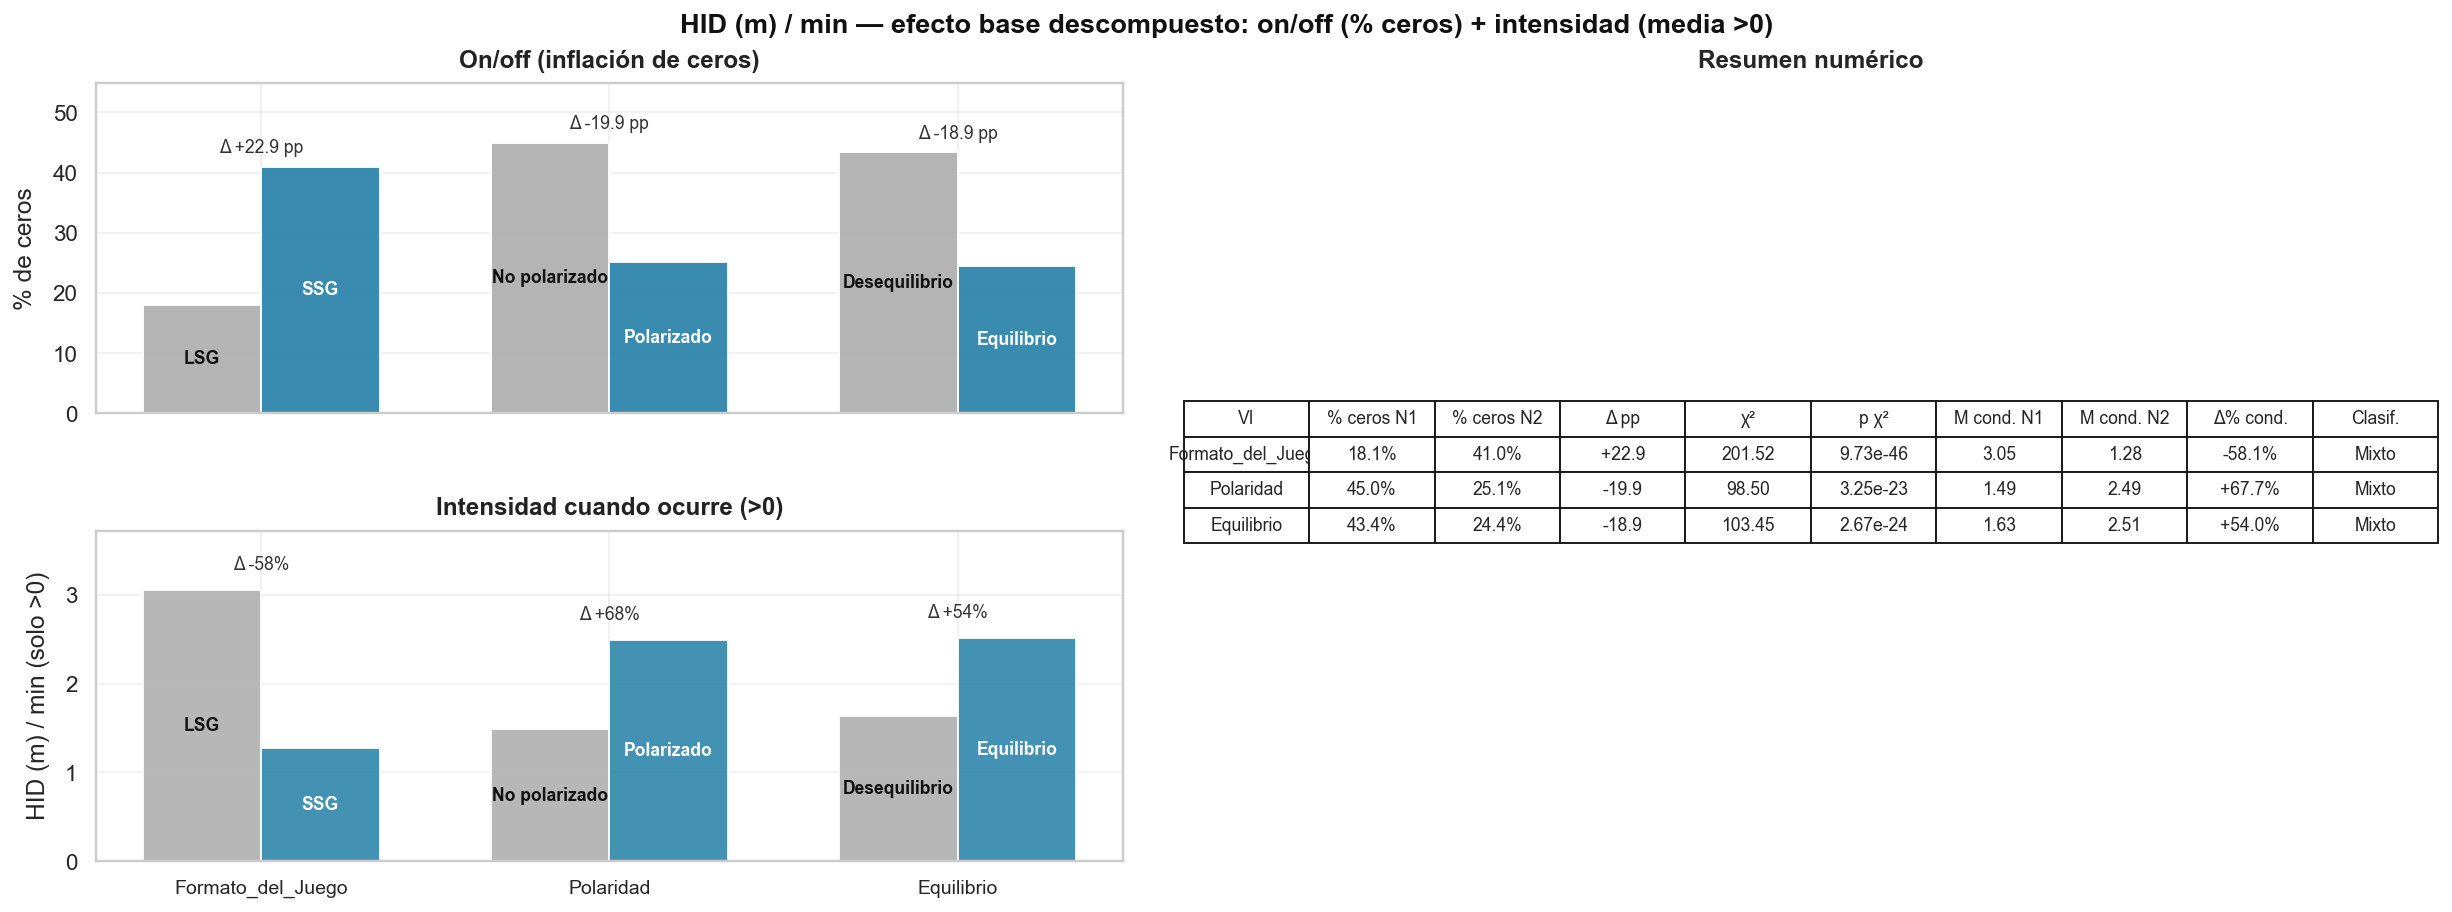

In [20]:
# ══════ Gráfico — Golpeos y HID (alternativa): paneles apilados (% ceros arriba + media >0 abajo) + tabla ══════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Fallbacks para ejecutar esta celda de forma independiente
if "df" not in globals():
    df = pd.read_excel("../Datos/Matriz_V3.xlsx")

if "vi_cols" not in globals():
    vi_cols = ["Formato_del_Juego", "Polaridad", "Equilibrio"]

if "vi_niveles" not in globals():
    vi_niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}


def _pretty_level(s: str) -> str:
    return str(s).replace("_", " ")


def _fmt_p(p: float) -> str:
    if not np.isfinite(p):
        return "—"
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.3f}"


def _clasificar(p_chi2: float, p_cond: float) -> str:
    sig_chi2 = np.isfinite(p_chi2) and p_chi2 < 0.05
    sig_cond = np.isfinite(p_cond) and p_cond < 0.05

    if sig_chi2 and sig_cond:
        return "Mixto"
    if sig_chi2 and not sig_cond:
        return "On/off (ceros)"
    if (not sig_chi2) and sig_cond:
        return "Intensidad (>0)"
    return "Negligible"


def _resumen_ceros_y_condicional(df: pd.DataFrame, vd_col: str, vi_cols: list[str]) -> pd.DataFrame:
    filas = []

    for vi in vi_cols:
        niveles = vi_niveles.get(vi, sorted(df[vi].dropna().unique().tolist()))
        if len(niveles) != 2:
            continue

        n1, n2 = niveles
        x1 = df.loc[df[vi] == n1, vd_col].dropna()
        x2 = df.loc[df[vi] == n2, vd_col].dropna()

        # % ceros
        z1 = float((x1 == 0).mean() * 100.0) if len(x1) else np.nan
        z2 = float((x2 == 0).mean() * 100.0) if len(x2) else np.nan
        delta_pp = (z2 - z1) if (np.isfinite(z1) and np.isfinite(z2)) else np.nan

        # χ² sobre tabla 2x2: (nivel) × (cero vs >0)
        c11 = int((x1 == 0).sum())
        c12 = int((x1 > 0).sum())
        c21 = int((x2 == 0).sum())
        c22 = int((x2 > 0).sum())

        chi2, p_chi2 = np.nan, np.nan
        try:
            chi2, p_chi2, _, _ = stats.chi2_contingency([[c11, c12], [c21, c22]], correction=False)
        except Exception:
            pass

        # Medias condicionales (>0)
        x1_pos = x1[x1 > 0]
        x2_pos = x2[x2 > 0]
        m1 = float(x1_pos.mean()) if len(x1_pos) else np.nan
        m2 = float(x2_pos.mean()) if len(x2_pos) else np.nan
        delta_pct_cond = ((m2 - m1) / m1 * 100.0) if (np.isfinite(m1) and m1 != 0 and np.isfinite(m2)) else np.nan

        # Test en parte condicional (Welch) para clasificar
        p_cond = np.nan
        try:
            if len(x1_pos) >= 2 and len(x2_pos) >= 2:
                _, p_cond = stats.ttest_ind(x1_pos, x2_pos, equal_var=False)
        except Exception:
            pass

        clasif = _clasificar(p_chi2, p_cond)

        filas.append({
            "VI": vi,
            "Nivel N1": str(n1),
            "Nivel N2": str(n2),
            "% ceros N1": z1,
            "% ceros N2": z2,
            "Δ pp": delta_pp,
            "χ²": chi2,
            "p χ²": p_chi2,
            "M cond. N1": m1,
            "M cond. N2": m2,
            "Δ% cond.": delta_pct_cond,
            "Clasif.": clasif,
        })

    out = pd.DataFrame(filas)
    if not out.empty:
        out["_orden"] = out["VI"].apply(lambda x: vi_cols.index(x) if x in vi_cols else 999)
        out = out.sort_values("_orden").drop(columns=["_orden"]).reset_index(drop=True)
    return out


def _label_inside(ax, rect, text: str, color: str, fontsize: int = 9):
    h = float(rect.get_height())
    if not np.isfinite(h):
        return

    y0, y1 = ax.get_ylim()
    y = h * 0.5
    if h <= 0:
        y = y0 + 0.02 * (y1 - y0)

    ax.text(
        rect.get_x() + rect.get_width() / 2,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=color,
        fontweight="bold",
        clip_on=True,
    )


def _plot_apilado_con_tabla(df_sum: pd.DataFrame, vd_label: str, xlabel_cond: str, fmt_cond: str = ".2f"):
    if df_sum.empty:
        return

    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

    fig = plt.figure(figsize=(17.4, 6.4), layout="constrained")
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[1.35, 1.65],
        height_ratios=[1.0, 1.0],
        wspace=0.05,
        hspace=0.08,
    )

    ax_z = fig.add_subplot(gs[0, 0])
    ax_m = fig.add_subplot(gs[1, 0], sharex=ax_z)
    ax_tbl = fig.add_subplot(gs[:, 1])

    x = np.arange(len(df_sum))
    w = 0.34

    lvl1 = df_sum["Nivel N1"].map(_pretty_level).to_list()
    lvl2 = df_sum["Nivel N2"].map(_pretty_level).to_list()

    # datos
    z1 = df_sum["% ceros N1"].to_numpy()
    z2 = df_sum["% ceros N2"].to_numpy()
    m1 = df_sum["M cond. N1"].to_numpy()
    m2 = df_sum["M cond. N2"].to_numpy()

    # estilo
    c_n1 = "#B0B0B0"  # N1
    c_n2 = "#2E86AB"  # N2

    # ── Panel superior: % ceros
    bars1 = ax_z.bar(x - w / 2, z1, width=w, color=c_n1, alpha=0.95)
    bars2 = ax_z.bar(x + w / 2, z2, width=w, color=c_n2, alpha=0.95)

    ax_z.set_ylabel("% de ceros")
    ax_z.set_title("On/off (inflación de ceros)", fontsize=12.5, fontweight="bold", color="#222", pad=8)
    ax_z.grid(axis="y", alpha=0.25)
    ax_z.set_axisbelow(True)

    zmax = float(np.nanmax(np.r_[z1, z2])) if np.isfinite(np.nanmax(np.r_[z1, z2])) else 100.0
    ax_z.set_ylim(0, min(100.0, zmax + 0.22 * max(zmax, 1.0)))

    # etiquetas dentro de barras
    for i, (r1, r2) in enumerate(zip(bars1, bars2)):
        _label_inside(ax_z, r1, lvl1[i], color="#111", fontsize=9)
        _label_inside(ax_z, r2, lvl2[i], color="white", fontsize=9)

    for i in range(len(df_sum)):
        dpp = df_sum.loc[i, "Δ pp"]
        if np.isfinite(dpp):
            ypp = max(z1[i], z2[i]) + 0.03 * ax_z.get_ylim()[1]
            ax_z.text(x[i], ypp, f"Δ {dpp:+.1f} pp", ha="center", va="bottom", fontsize=9, color="#333")

    # ── Panel inferior: media condicional >0
    bars3 = ax_m.bar(x - w / 2, m1, width=w, color=c_n1, alpha=0.90)
    bars4 = ax_m.bar(x + w / 2, m2, width=w, color=c_n2, alpha=0.90)

    ax_m.set_ylabel(xlabel_cond)
    ax_m.set_title("Intensidad cuando ocurre (>0)", fontsize=12.5, fontweight="bold", color="#222", pad=8)
    ax_m.grid(axis="y", alpha=0.25)
    ax_m.set_axisbelow(True)

    mmax = float(np.nanmax(np.r_[m1, m2])) if np.isfinite(np.nanmax(np.r_[m1, m2])) else 1.0
    ax_m.set_ylim(0, mmax + 0.22 * max(mmax, 1e-9))

    for i, (r1, r2) in enumerate(zip(bars3, bars4)):
        _label_inside(ax_m, r1, lvl1[i], color="#111", fontsize=9)
        _label_inside(ax_m, r2, lvl2[i], color="white", fontsize=9)

    for i in range(len(df_sum)):
        dpc = df_sum.loc[i, "Δ% cond."]
        if np.isfinite(dpc):
            ypc = max(m1[i], m2[i]) + 0.05 * ax_m.get_ylim()[1]
            ax_m.text(x[i], ypc, f"Δ {dpc:+.0f}%", ha="center", va="bottom", fontsize=9, color="#333")

    # eje X: solo VI
    ax_m.set_xticks(x)
    ax_m.set_xticklabels(df_sum["VI"].to_list(), fontsize=10)
    ax_z.tick_params(axis="x", labelbottom=False)

    # Título general
    fig.suptitle(
        f"{vd_label} — efecto base descompuesto: on/off (% ceros) + intensidad (media >0)",
        fontsize=14,
        fontweight="bold",
        color="#111",
    )

    # ── Tabla resumen
    cols_tbl = ["VI", "% ceros N1", "% ceros N2", "Δ pp", "χ²", "p χ²", "M cond. N1", "M cond. N2", "Δ% cond.", "Clasif."]
    tbl = df_sum.loc[:, cols_tbl].copy()

    def _fmt_pct(x):
        return "—" if not np.isfinite(x) else f"{x:.1f}%"

    def _fmt_num(x, fmt):
        return "—" if not np.isfinite(x) else format(float(x), fmt)

    tbl["% ceros N1"] = tbl["% ceros N1"].apply(_fmt_pct)
    tbl["% ceros N2"] = tbl["% ceros N2"].apply(_fmt_pct)
    tbl["Δ pp"] = tbl["Δ pp"].apply(lambda x: "—" if not np.isfinite(x) else f"{x:+.1f}")
    tbl["χ²"] = tbl["χ²"].apply(lambda x: _fmt_num(x, ".2f"))
    tbl["p χ²"] = tbl["p χ²"].apply(_fmt_p)
    tbl["M cond. N1"] = tbl["M cond. N1"].apply(lambda x: _fmt_num(x, fmt_cond))
    tbl["M cond. N2"] = tbl["M cond. N2"].apply(lambda x: _fmt_num(x, fmt_cond))
    tbl["Δ% cond."] = tbl["Δ% cond."].apply(lambda x: "—" if not np.isfinite(x) else f"{x:+.1f}%")

    ax_tbl.axis("off")
    ax_tbl.set_title("Resumen numérico", fontsize=12.5, fontweight="bold", pad=8)

    table = ax_tbl.table(
        cellText=tbl.values,
        colLabels=tbl.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.35)

    plt.show()


vd_targets = [
    ("Golpeos +15 m/s / min", "Golpeos +15 m/s / min", "Golpeos +15 m/s / min (solo >0)", ".2f"),
    ("High Intensity Distance (20 km/h) / min", "HID (m) / min", "HID (m) / min (solo >0)", ".2f"),
]

for vd_col, vd_label, xlabel_cond, fmt_cond in vd_targets:
    df_sum = _resumen_ceros_y_condicional(df=df, vd_col=vd_col, vi_cols=vi_cols)
    _plot_apilado_con_tabla(df_sum, vd_label=vd_label, xlabel_cond=xlabel_cond, fmt_cond=fmt_cond)

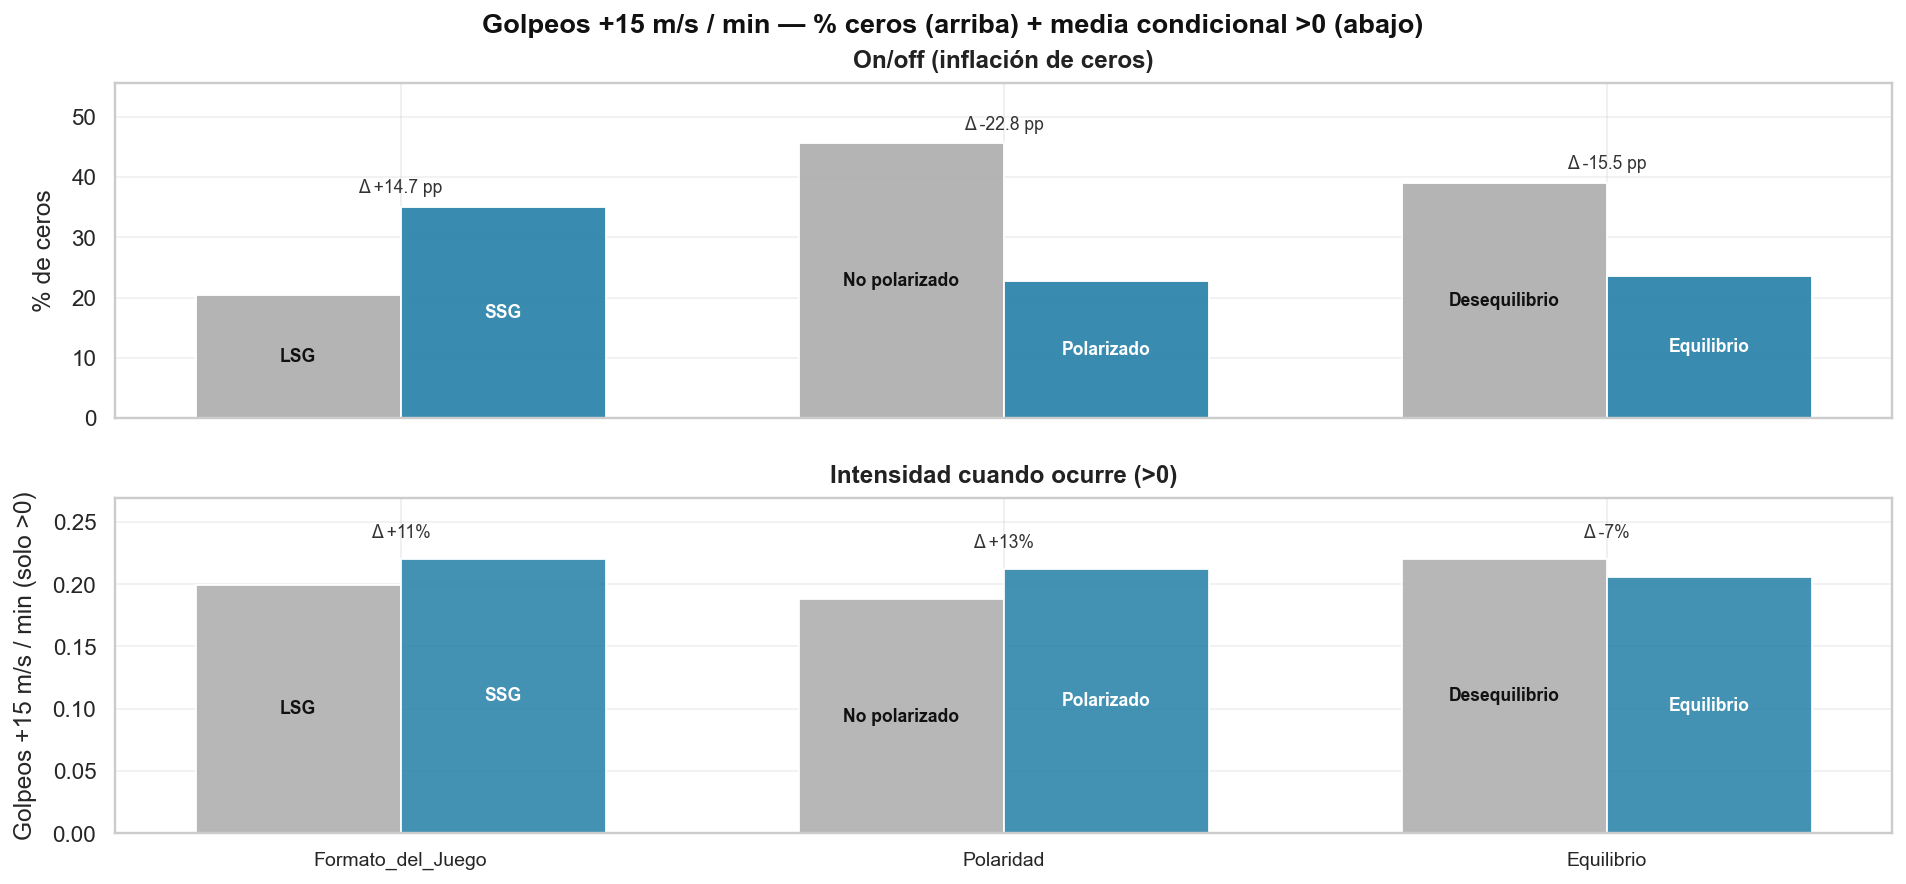

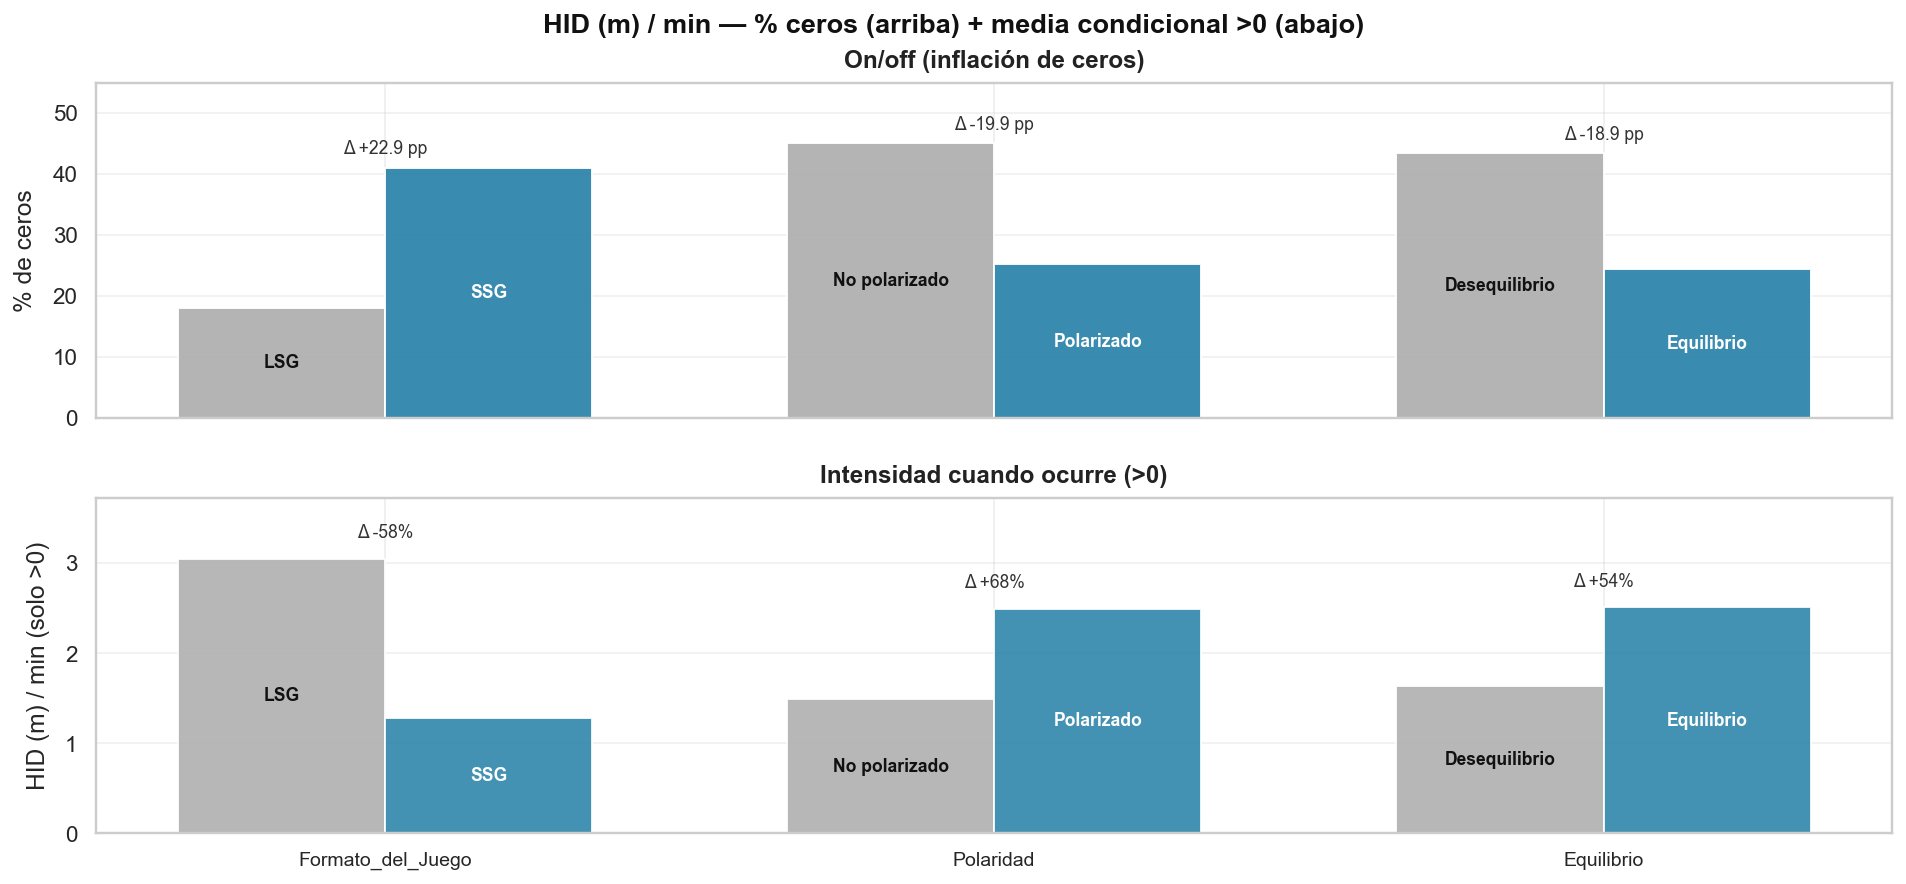

In [21]:
# ══════ Gráfico (sin tabla) — Golpeos y HID (alternativa): paneles apilados (% ceros arriba + media >0 abajo) ══════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fallbacks para ejecutar esta celda de forma independiente
if "df" not in globals():
    df = pd.read_excel("../Datos/Matriz_V3.xlsx")

if "vi_cols" not in globals():
    vi_cols = ["Formato_del_Juego", "Polaridad", "Equilibrio"]

if "vi_niveles" not in globals():
    vi_niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}


def _pretty_level(s: str) -> str:
    return str(s).replace("_", " ")


if "_resumen_ceros_y_condicional" not in globals():
    def _resumen_ceros_y_condicional(df: pd.DataFrame, vd_col: str, vi_cols: list[str]) -> pd.DataFrame:
        filas = []
        for vi in vi_cols:
            niveles = vi_niveles.get(vi, sorted(df[vi].dropna().unique().tolist()))
            if len(niveles) != 2:
                continue

            n1, n2 = niveles
            x1 = df.loc[df[vi] == n1, vd_col].dropna()
            x2 = df.loc[df[vi] == n2, vd_col].dropna()

            z1 = float((x1 == 0).mean() * 100.0) if len(x1) else np.nan
            z2 = float((x2 == 0).mean() * 100.0) if len(x2) else np.nan
            delta_pp = (z2 - z1) if (np.isfinite(z1) and np.isfinite(z2)) else np.nan

            x1_pos = x1[x1 > 0]
            x2_pos = x2[x2 > 0]
            m1 = float(x1_pos.mean()) if len(x1_pos) else np.nan
            m2 = float(x2_pos.mean()) if len(x2_pos) else np.nan
            delta_pct_cond = ((m2 - m1) / m1 * 100.0) if (np.isfinite(m1) and m1 != 0 and np.isfinite(m2)) else np.nan

            filas.append({
                "VI": vi,
                "Nivel N1": str(n1),
                "Nivel N2": str(n2),
                "% ceros N1": z1,
                "% ceros N2": z2,
                "Δ pp": delta_pp,
                "M cond. N1": m1,
                "M cond. N2": m2,
                "Δ% cond.": delta_pct_cond,
            })

        out = pd.DataFrame(filas)
        if not out.empty:
            out["_orden"] = out["VI"].apply(lambda x: vi_cols.index(x) if x in vi_cols else 999)
            out = out.sort_values("_orden").drop(columns=["_orden"]).reset_index(drop=True)
        return out


def _label_inside(ax, rect, text: str, color: str, fontsize: int = 9):
    h = float(rect.get_height())
    if not np.isfinite(h):
        return

    y0, y1 = ax.get_ylim()
    y = h * 0.5
    if h <= 0:
        y = y0 + 0.02 * (y1 - y0)

    ax.text(
        rect.get_x() + rect.get_width() / 2,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=color,
        fontweight="bold",
        clip_on=True,
    )


def _plot_apilado_sin_tabla(df_sum: pd.DataFrame, vd_label: str, xlabel_cond: str):
    if df_sum.empty:
        return

    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

    fig, (ax_z, ax_m) = plt.subplots(
        2,
        1,
        figsize=(13.5, 6.2),
        sharex=True,
        layout="constrained",
        gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.08},
    )

    x = np.arange(len(df_sum))
    w = 0.34

    lvl1 = df_sum["Nivel N1"].map(_pretty_level).to_list()
    lvl2 = df_sum["Nivel N2"].map(_pretty_level).to_list()

    z1 = df_sum["% ceros N1"].to_numpy()
    z2 = df_sum["% ceros N2"].to_numpy()
    m1 = df_sum["M cond. N1"].to_numpy()
    m2 = df_sum["M cond. N2"].to_numpy()

    c_n1 = "#B0B0B0"
    c_n2 = "#2E86AB"

    # % ceros
    bars1 = ax_z.bar(x - w / 2, z1, width=w, color=c_n1, alpha=0.95)
    bars2 = ax_z.bar(x + w / 2, z2, width=w, color=c_n2, alpha=0.95)
    ax_z.set_ylabel("% de ceros")
    ax_z.set_title("On/off (inflación de ceros)", fontsize=12.5, fontweight="bold", color="#222", pad=8)
    ax_z.grid(axis="y", alpha=0.25)
    ax_z.set_axisbelow(True)

    zmax = float(np.nanmax(np.r_[z1, z2])) if np.isfinite(np.nanmax(np.r_[z1, z2])) else 100.0
    ax_z.set_ylim(0, min(100.0, zmax + 0.22 * max(zmax, 1.0)))

    for i, (r1, r2) in enumerate(zip(bars1, bars2)):
        _label_inside(ax_z, r1, lvl1[i], color="#111", fontsize=9)
        _label_inside(ax_z, r2, lvl2[i], color="white", fontsize=9)

    for i in range(len(df_sum)):
        dpp = df_sum.loc[i, "Δ pp"]
        if np.isfinite(dpp):
            ypp = max(z1[i], z2[i]) + 0.03 * ax_z.get_ylim()[1]
            ax_z.text(x[i], ypp, f"Δ {dpp:+.1f} pp", ha="center", va="bottom", fontsize=9, color="#333")

    # media >0
    bars3 = ax_m.bar(x - w / 2, m1, width=w, color=c_n1, alpha=0.90)
    bars4 = ax_m.bar(x + w / 2, m2, width=w, color=c_n2, alpha=0.90)
    ax_m.set_ylabel(xlabel_cond)
    ax_m.set_title("Intensidad cuando ocurre (>0)", fontsize=12.5, fontweight="bold", color="#222", pad=8)
    ax_m.grid(axis="y", alpha=0.25)
    ax_m.set_axisbelow(True)

    mmax = float(np.nanmax(np.r_[m1, m2])) if np.isfinite(np.nanmax(np.r_[m1, m2])) else 1.0
    ax_m.set_ylim(0, mmax + 0.22 * max(mmax, 1e-9))

    for i, (r1, r2) in enumerate(zip(bars3, bars4)):
        _label_inside(ax_m, r1, lvl1[i], color="#111", fontsize=9)
        _label_inside(ax_m, r2, lvl2[i], color="white", fontsize=9)

    for i in range(len(df_sum)):
        dpc = df_sum.loc[i, "Δ% cond."]
        if np.isfinite(dpc):
            ypc = max(m1[i], m2[i]) + 0.05 * ax_m.get_ylim()[1]
            ax_m.text(x[i], ypc, f"Δ {dpc:+.0f}%", ha="center", va="bottom", fontsize=9, color="#333")

    # eje X: solo VI
    ax_m.set_xticks(x)
    ax_m.set_xticklabels(df_sum["VI"].to_list(), fontsize=10)

    fig.suptitle(
        f"{vd_label} — % ceros (arriba) + media condicional >0 (abajo)",
        fontsize=14,
        fontweight="bold",
        color="#111",
    )

    plt.show()


vd_targets = [
    ("Golpeos +15 m/s / min", "Golpeos +15 m/s / min", "Golpeos +15 m/s / min (solo >0)"),
    ("High Intensity Distance (20 km/h) / min", "HID (m) / min", "HID (m) / min (solo >0)"),
]

for vd_col, vd_label, xlabel_cond in vd_targets:
    df_sum = _resumen_ceros_y_condicional(df=df, vd_col=vd_col, vi_cols=vi_cols)
    _plot_apilado_sin_tabla(df_sum, vd_label=vd_label, xlabel_cond=xlabel_cond)

In [22]:
# ── Tabla resumen para PowerPoint: Golpeos y HID ──────────
# Extraer datos de df_zeros y calcular clasificación

vd_zeros_target = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels_target = ["Golpeos +15 m/s / min", "HID (m) / min"]

umbral_pct_ceros = 5.0   # pp de diferencia en % ceros para considerar "Interruptor"
umbral_pct_media = 10.0  # % de diferencia relativa en media cond. para considerar "Modulador"

# Procesar datos para tabla
tabla_golpeos_hid = []

for vd, label in zip(vd_zeros_target, vd_zeros_labels_target):
    for vi in vi_cols:
        # Obtener datos por nivel
        datos_vi = df_zeros[(df_zeros['VD'] == label) & (df_zeros['VI'] == vi)].copy()
        
        if len(datos_vi) == 2:  # Debe haber exactamente 2 niveles
            n1_data = datos_vi.iloc[0]
            n2_data = datos_vi.iloc[1]
            
            # Para HID, ordenar por MENOR % de ceros (más actividad)
            # Para Golpeos, ordenar por MAYOR % de ceros (como antes)
            if label == "HID (m) / min":
                # Invertir si n1 tiene más ceros que n2
                if n1_data['% ceros'] > n2_data['% ceros']:
                    n1_data, n2_data = n2_data, n1_data
            else:
                # Para Golpeos: mantener el que tiene más ceros como N1
                if n1_data['% ceros'] < n2_data['% ceros']:
                    n1_data, n2_data = n2_data, n1_data
            
            # Calcular diferencias
            d_pct_ceros = abs(n1_data['% ceros'] - n2_data['% ceros'])
            
            # Diferencia porcentual en media condicional
            media_ref = max(n1_data['Media cond. (>0)'], n2_data['Media cond. (>0)'])
            if media_ref > 0 and not pd.isna(n1_data['Media cond. (>0)']) and not pd.isna(n2_data['Media cond. (>0)']):
                d_media_cond_pct = abs(n1_data['Media cond. (>0)'] - n2_data['Media cond. (>0)']) / media_ref * 100
            else:
                d_media_cond_pct = 0
            
            # Clasificación
            es_inter = d_pct_ceros >= umbral_pct_ceros
            es_modul = d_media_cond_pct >= umbral_pct_media
            if es_inter and es_modul:
                clasificacion = "Ambos"
            elif es_inter:
                clasificacion = "Interruptor"
            elif es_modul:
                clasificacion = "Modulador"
            else:
                clasificacion = "Neutro"
            
            tabla_golpeos_hid.append({
                'VD': label,
                'VI': vi,
                'Nivel 1': n1_data['Nivel'],
                '% ceros N1': n1_data['% ceros'],
                'Nivel 2': n2_data['Nivel'],
                '% ceros N2': n2_data['% ceros'],
                'Δ pp': round(d_pct_ceros, 1),
                'M cond. N1': round(n1_data['Media cond. (>0)'], 4),
                'M cond. N2': round(n2_data['Media cond. (>0)'], 4),
                'Δ% cond.': round(d_media_cond_pct, 1),
                'Clasif.': clasificacion
            })

df_tabla_golpeos_hid = pd.DataFrame(tabla_golpeos_hid)
print("=" * 100)
print("Nota: Para HID, Nivel 1 = menor % ceros (más actividad de alta intensidad)")
print("      Para Golpeos, Nivel 1 = mayor % ceros")
print("=" * 100)
display(df_tabla_golpeos_hid)

Nota: Para HID, Nivel 1 = menor % ceros (más actividad de alta intensidad)
      Para Golpeos, Nivel 1 = mayor % ceros


,VD,VI,Nivel 1,% ceros N1,Nivel 2,% ceros N2,Δ pp,M cond. N1,M cond. N2,Δ% cond.,Clasif.
0,Golpeos +15 m/s / min,Formato_del_Juego,SSG,35.0,LSG,20.3,14.7,0.2205,0.1994,9.6,Interruptor
1,Golpeos +15 m/s / min,Polaridad,No_polarizado,45.6,Polarizado,22.8,22.8,0.1877,0.2124,11.6,Ambos
2,Golpeos +15 m/s / min,Equilibrio,Desequilibrio,39.1,Equilibrio,23.6,15.5,0.2203,0.2055,6.7,Interruptor
3,HID (m) / min,Formato_del_Juego,LSG,18.1,SSG,41.0,22.9,3.0501,1.2784,58.1,Ambos
4,HID (m) / min,Polaridad,Polarizado,25.1,No_polarizado,45.0,19.9,2.4935,1.4870,40.4,Ambos
5,HID (m) / min,Equilibrio,Equilibrio,24.4,Desequilibrio,43.4,19.0,2.5106,1.6303,35.1,Ambos
